In [44]:
import pandas as pd

#df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/172_Completedresults_survey123456.csv')

df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/200_Complete_final_data2process.csv')

# List all columns containing Q00 to spot the correct one
#print([col for col in df.columns if 'Q00. How often do you use public transport services' in col])


In [46]:
import os

# Get current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)


Current working directory: /Users/syed/Downloads/Applications/Companies/Thesis/Coding


In [48]:
import os
os.chdir('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/')
print("Changed working directory to:", os.getcwd())


Changed working directory to: /Users/syed/Downloads/Applications/Companies/Thesis/Coding


In [50]:
import numpy as np

interview_time_min = interview_time / 60  # Converts seconds to minutes

mean = interview_time_min.mean()
sd = interview_time_min.std()
min_val = interview_time_min.min()
q1 = interview_time_min.quantile(0.25)
median = interview_time_min.median()
q3 = interview_time_min.quantile(0.75)
max_val = interview_time_min.max()
n = interview_time_min.count()

# LaTeX table string
latex_table = f"""
\\begin{{tabular}}{{llllllll}}
\\toprule
Statistics & Mean & SD & Min & 1^{{st}} Q. & Median & 3^{{rd}} Q. & Max \\\\
\\midrule
Minutes & {mean:.2f} & {sd:.2f} & {min_val:.2f} & {q1:.2f} & {median:.2f} & {q3:.2f} & {max_val:.2f} \\\\
\\bottomrule
\\end{{tabular}}
\\\\
N = {n}
"""
print(latex_table)



\begin{tabular}{llllllll}
\toprule
Statistics & Mean & SD & Min & 1^{st} Q. & Median & 3^{rd} Q. & Max \\
\midrule
Minutes & 10.43 & 8.52 & 2.79 & 6.91 & 8.70 & 11.68 & 104.58 \\
\bottomrule
\end{tabular}
\\
N = 201



Original data points: 201
Cleaned data points: 197
Outliers removed: 4


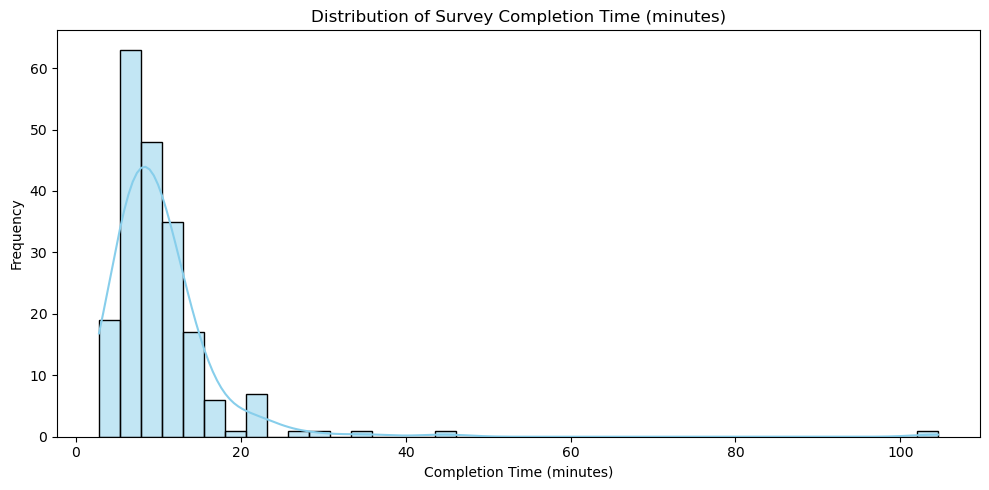

In [52]:
# Replace 'interviewtime. Total time' with the exact column name from your dataset
column_name = 'interviewtime. Total time'  # verify this

# Check data type
if pd.api.types.is_numeric_dtype(df[column_name]):
    interview_time = df[column_name]
else:
    # For non-numeric data, try converting from string to float after cleaning
    interview_time = pd.to_numeric(df[column_name], errors='coerce')  # invalid parsing will become NaN

# Continue with descriptive stats and filtering
stats = interview_time.describe()

# Plot distribution
import matplotlib.pyplot as plt
import seaborn as sns

#plt.figure(figsize=(10, 5))
#sns.histplot(interview_time.dropna(), bins=40, kde=True)
#plt.xlabel('Completion Time (seconds)')
#plt.title('Distribution of Survey Completion Time')
#plt.show()

# Thresholds at 1st and 99th percentile
lower_thresh = interview_time.quantile(0.01)
upper_thresh = interview_time.quantile(0.99)

# Filter out outliers
clean_df = df[(interview_time >= lower_thresh) & (interview_time <= upper_thresh)]

print(f"Original data points: {len(df)}")
print(f"Cleaned data points: {len(clean_df)}")
print(f"Outliers removed: {len(df) - len(clean_df)}")

plt.figure(figsize=(10,5))
sns.histplot(interview_time_min.dropna(), bins=40, kde=True, color='skyblue')
plt.title('Distribution of Survey Completion Time (minutes)')
plt.xlabel('Completion Time (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/survey_response_time_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
df = clean_df

In [55]:
df.columns

Index(['id. Response ID', 'submitdate. Date submitted', 'lastpage. Last page',
       'startlanguage. Start language', 'seed. Seed',
       'startdate. Date started', 'datestamp. Date last action',
       'G01Q63. Dear Participant(s),  Thank you very much for your interest in this research, and welcome to the survey.  My name is Syed, and I am conducting this survey as part of my Master's research project at the Technical University of Munich (TUM), under t',
       'G01Q62. {if(is_empty(G01Q62), rand(1,4), G01Q62)} ',
       'Q00. How often do you use public transport services for intercity (long-distance) travel, i.e. +/- 100 km or longer trips? ',
       ...
       'G15Q22Time. Question time: G15Q22',
       'G01Q23Time. Question time: G01Q23',
       'G01Q24Time. Question time: G01Q24',
       'G15Q25Time. Question time: G15Q25',
       'G15Q26Time. Question time: G15Q26',
       'G01Q27Time. Question time: G01Q27',
       'G01Q29Time. Question time: G01Q29',
       'G01Q28Time. Qu

In [56]:
import numpy as np

def extract_attributes_for_TrainA(df, id_col='id. Response ID'):
    """
    For each respondent and scenario column where 'Train A' is selected,
    extracts zugA_time and zugA_cost attributes based on the column header.
    
    Parameters:
        df : pandas DataFrame with respondent ID and scenario columns
        id_col : column name of respondent identifier
    
    Returns:
        pandas DataFrame with columns:
            - Respondent
            - Scenario
            - time_STR_BERA (int, 2 or 4)
            - zugA_cost (float, 30 or 60 etc. extracted from header)
    """
    rows = []
    scenario_cols = [col for col in df.columns if col != id_col]

    for _, row in df.iterrows():
        respondent_id = row[id_col]
        for scenario in scenario_cols:
            choice = row[scenario]
            if choice == 'Train A':
                # Extract time (2 or 4) from e.g., T2, T4 in header
                time_part = None
                if '_T2_' in scenario:
                    time_part = 2
                elif '_T4_' in scenario:
                    time_part = 4
                else:
                    # In case format differs, try regex or skip
                    time_part = np.nan
                
                # Extract cost for Train A which is the first value before '/'
                try:
                    c_part = scenario.split('_C:')[1].split('_')[0]  # e.g., '30/45'
                    cost_trainA = float(c_part.split('/')[0])
                except Exception:
                    cost_trainA = np.nan
                
                rows.append({
                    id_col: respondent_id,
                    'Scenario': scenario,
                    'time_STR_BERA': time_part,
                    'zugA_cost': cost_trainA
                })

    return pd.DataFrame(rows)


# Example use:
# df is your DataFrame with respondent IDs in 'Respondent' and SP scenario columns as described.
zugA_df = extract_attributes_for_TrainA(df)

print(zugA_df.head())

   id. Response ID                              Scenario  time_STR_BERA  \
0               28    G05Q30TC3_T2_C:30/45_HL/LS_STR01.               2   
1               28   G05Q38NTC2_T4_C:60/90_HL/LL_BER03.               4   
2               28   G05Q40NTC3_T4_C:60/90_HL/LS_BER05.               4   
3               30  G02Q07NTC4_T2_C:30/45_HS/LS_STR01.                2   
4               30   G02Q09NTC2_T2_C:30/45_HL/LL_STR03.               2   

   zugA_cost  
0       30.0  
1       60.0  
2       60.0  
3       30.0  
4       30.0  


In [57]:
def extract_attributes_for_TrainB(df, id_col='id. Response ID'):
    """
    For each respondent and scenario column where 'Train B' is selected,
    extracts zugB_time and zugB_cost attributes based on the column header.
    
    Parameters:
        df : pandas DataFrame with respondent ID and scenario columns
        id_col : column name of respondent identifier
    
    Returns:
        pandas DataFrame with columns:
            - Respondent
            - Scenario
            - time_STR_BERB (int, 2 or 4)
            - zugB_cost (float, 45 or 90 etc. extracted from header)
    """
    rows = []
    scenario_cols = [col for col in df.columns if col != id_col]

    for _, row in df.iterrows():
        respondent_id = row[id_col]
        for scenario in scenario_cols:
            choice = row[scenario]
            if choice == 'Train B':
                # Extract time (2 or 4) from _T2_ or _T4_ in header
                time_part = None
                if '_T2_' in scenario:
                    time_part = 2
                elif '_T4_' in scenario:
                    time_part = 4
                else:
                    time_part = np.nan
                
                # Extract cost for Train B which is the second value after '/'
                try:
                    c_part = scenario.split('_C:')[1].split('_')[0]  # e.g., '30/45'
                    cost_trainB = float(c_part.split('/')[1])
                except Exception:
                    cost_trainB = np.nan
                
                rows.append({
                    id_col: respondent_id,
                    'Scenario': scenario,
                    'time_STR_BERB': time_part,
                    'zugB_cost': cost_trainB
                })

    return pd.DataFrame(rows)

# Example usage:
zugB_df = extract_attributes_for_TrainB(df)

print(zugB_df.head())


   id. Response ID                             Scenario  time_STR_BERB  \
0               28  G05Q31NTC3_T2_C:30/45_HL/LS_STR02.               2   
1               28   G05Q32TC4_T2_C:30/45_HS/LS_STR03.               2   
2               28  G05Q33NTC5_T2_C:30/45_LL/LS_STR04.               2   
3               28   G05Q34TC1_T2_C:30/45_HL/HS_STR05.               2   
4               28  G05Q36NTC4_T4_C:60/90_HS/LS_BER01.               4   

   zugB_cost  
0       45.0  
1       45.0  
2       45.0  
3       45.0  
4       90.0  


In [58]:
# Extracted DataFrames with cost and time columns
zugA_df = extract_attributes_for_TrainA(df)
zugB_df = extract_attributes_for_TrainB(df)

# Merge on id and Scenario
combined_df_CT_merge = zugA_df.merge(zugB_df, on=['id. Response ID', 'Scenario'], how='outer')

# Now you can create a combined cost/time in combined_df
combined_df_CT_merge['Chosen_Cost'] = combined_df_CT_merge['zugA_cost'].combine_first(combined_df_CT_merge['zugB_cost'])
combined_df_CT_merge['Chosen_Time'] = combined_df_CT_merge['time_STR_BERA'].combine_first(combined_df_CT_merge['time_STR_BERB'])


# Remove duplicates in zugB_df
#combined_df_CT_merge = combined_df_CT_merge.drop(columns=['zugA_cost', 'zugA_time', 'zugB_cost', 'zugB_time'], errors='ignore')

print("Columns in combined_df_CT_merge before dropping:")
print(combined_df_CT_merge.columns.tolist())

#cols_to_remove = ['zugA_cost', 'zugA_time', 'zugB_cost', 'zugB_time']
#existing_cols_to_remove = [col for col in cols_to_remove if col in combined_df_CT_merge.columns]

#combined_df_CT_merge = combined_df_CT_merge.drop(columns=existing_cols_to_remove)


cols_to_print = ['id. Response ID', 'Scenario', 'zugA_cost', 'zugB_cost', 'Chosen_Cost', 'Chosen_Time', 'time_STR_BER', 'zugB_time']
existing_cols_to_print = [col for col in cols_to_print if col in combined_df_CT_merge.columns]

print(combined_df_CT_merge[existing_cols_to_print].head())

Columns in combined_df_CT_merge before dropping:
['id. Response ID', 'Scenario', 'time_STR_BERA', 'zugA_cost', 'time_STR_BERB', 'zugB_cost', 'Chosen_Cost', 'Chosen_Time']
   id. Response ID                             Scenario  zugA_cost  zugB_cost  \
0               28   G05Q30TC3_T2_C:30/45_HL/LS_STR01.        30.0        NaN   
1               28  G05Q31NTC3_T2_C:30/45_HL/LS_STR02.         NaN       45.0   
2               28   G05Q32TC4_T2_C:30/45_HS/LS_STR03.         NaN       45.0   
3               28  G05Q33NTC5_T2_C:30/45_LL/LS_STR04.         NaN       45.0   
4               28   G05Q34TC1_T2_C:30/45_HL/HS_STR05.         NaN       45.0   

   Chosen_Cost  Chosen_Time  
0         30.0          2.0  
1         45.0          2.0  
2         45.0          2.0  
3         45.0          2.0  
4         45.0          2.0  


In [59]:
def extract_trip_purpose(df, id_col='id. Response ID'):
    """
    Extracts trip purpose (TC or NTC) for each scenario column header
    and assigns trip purpose per respondent + scenario.

    Returns a DataFrame with:
    - Respondent
    - Scenario
    - TripPurpose ('TC' or 'NTC')
    """

    rows = []
    scenario_cols = [col for col in df.columns if col != id_col]

    for _, row in df.iterrows():
        respondent_id = row[id_col]
        for scenario in scenario_cols:
            if 'NTC' in scenario:
                trip_purpose = 'Non_Time_Critical'
            elif 'TC' in scenario:
                trip_purpose = 'Time_Critical'
            else:
                trip_purpose = 'Unknown'


            # Only process if choice is non-empty (Train A or B)
            if pd.notna(row[scenario]) and row[scenario] in ['Train A', 'Train B']:
                rows.append({
                    id_col: respondent_id,
                    'Scenario': scenario,
                    'TripPurpose': trip_purpose
                })

    return pd.DataFrame(rows)

# Example usage:
trip_purpose_df = extract_trip_purpose(df)

#df['trip_purpose_df'] = df['trip_purpose_df'].astype('category').cat.codes
print(trip_purpose_df.head())

mapping = {'Time_Critical': 1, 'Non_Time_Critical': 0}

trip_purpose_df['TripPurpose_Code'] = trip_purpose_df['TripPurpose'].map(mapping)

print(trip_purpose_df[['TripPurpose', 'TripPurpose_Code']].head())



   id. Response ID                             Scenario        TripPurpose
0               28   G05Q30TC3_T2_C:30/45_HL/LS_STR01.       Time_Critical
1               28  G05Q31NTC3_T2_C:30/45_HL/LS_STR02.   Non_Time_Critical
2               28   G05Q32TC4_T2_C:30/45_HS/LS_STR03.       Time_Critical
3               28  G05Q33NTC5_T2_C:30/45_LL/LS_STR04.   Non_Time_Critical
4               28   G05Q34TC1_T2_C:30/45_HL/HS_STR05.       Time_Critical
         TripPurpose  TripPurpose_Code
0      Time_Critical                 1
1  Non_Time_Critical                 0
2      Time_Critical                 1
3  Non_Time_Critical                 0
4      Time_Critical                 1


In [60]:
def extract_delay_attributes(df, id_col='id. Response ID'):
    """
    Extracts binary delay risk attributes for Train A and Train B choices
    from column header reliability codes like 'HL/HS', 'HL/LL', etc.
    
    Parameters:
        df : pandas DataFrame with respondent ID and scenario columns
        id_col : name of respondent ID column
    
    Returns:
        pandas DataFrame in long format with columns:
            - Respondent
            - Scenario
            - zugA_delay_LS, zugA_delay_LL, zugA_delay_HS, zugA_delay_HL (0/1)
            - zugB_delay_LS, zugB_delay_LL, zugB_delay_HS, zugB_delay_HL (0/1)
    """
    delay_codes = ['LS', 'LL', 'HS', 'HL']
    rows = []
    scenario_cols = [col for col in df.columns if col != id_col]

    for _, row in df.iterrows():
        respondent_id = row[id_col]
        for scenario in scenario_cols:
            choice = row[scenario]
            if pd.isna(choice) or choice not in ['Train A', 'Train B']:
                # Skip missing or unassigned
                continue
            
            # Extract reliability from header, e.g. 'HL/HS'
            try:
                rel_part = scenario.split('_C:')[1].split('_')[1]  # e.g. 'HS/LS'
            except IndexError:
                # Fallback if format unexpected
                rel_part = None
            
            if rel_part and '/' in rel_part:
                trainA_rel, trainB_rel = rel_part.split('/')
            else:
                trainA_rel, trainB_rel = None, None
            
            # Initialize all binary delay columns as 0
            delay_a = {f'zugA_delay_{code}': 0 for code in delay_codes}
            delay_b = {f'zugB_delay_{code}': 0 for code in delay_codes}
            
            # Set 1 for appropriate delay level of chosen alternative
            if choice == 'Train A' and trainA_rel in delay_codes:
                delay_a[f'zugA_delay_{trainA_rel}'] = 1
            elif choice == 'Train B' and trainB_rel in delay_codes:
                delay_b[f'zugB_delay_{trainB_rel}'] = 1
            
            row_dict = {
                id_col: respondent_id,
                'Scenario': scenario,
            }
            row_dict.update(delay_a)
            row_dict.update(delay_b)
            
            rows.append(row_dict)
    
    return pd.DataFrame(rows)


delay_df = extract_delay_attributes(df)
print(delay_df.head())

has_nans_delay_df = delay_df.isnull().values.any()
print(has_nans_delay_df)  # True if any NaN exists anywhere in df, otherwise False

   id. Response ID                             Scenario  zugA_delay_LS  \
0               28   G05Q30TC3_T2_C:30/45_HL/LS_STR01.               0   
1               28  G05Q31NTC3_T2_C:30/45_HL/LS_STR02.               0   
2               28   G05Q32TC4_T2_C:30/45_HS/LS_STR03.               0   
3               28  G05Q33NTC5_T2_C:30/45_LL/LS_STR04.               0   
4               28   G05Q34TC1_T2_C:30/45_HL/HS_STR05.               0   

   zugA_delay_LL  zugA_delay_HS  zugA_delay_HL  zugB_delay_LS  zugB_delay_LL  \
0              0              0              1              0              0   
1              0              0              0              1              0   
2              0              0              0              1              0   
3              0              0              0              1              0   
4              0              0              0              0              0   

   zugB_delay_HS  zugB_delay_HL  
0              0              0  
1     

In [61]:
# List of delay indicator columns for Zug A and Zug B
zugA_cols = ['zugA_delay_LS', 'zugA_delay_LL', 'zugA_delay_HS', 'zugA_delay_HL']
zugB_cols = ['zugB_delay_LS', 'zugB_delay_LL', 'zugB_delay_HS', 'zugB_delay_HL']

# Create Choice_ZugA column: 1 if any of Zug A delay indicators is 1, else 0
delay_df['Choice_ZugA'] = (delay_df[zugA_cols].sum(axis=1) > 0).astype(int)

# Create Choice_ZugB column: 1 if any of Zug B delay indicators is 1, else 0
delay_df['Choice_ZugB'] = (delay_df[zugB_cols].sum(axis=1) > 0).astype(int)

# Now delay_df has the two new columns indicating which Zug was chosen per row



print(delay_df[['Choice_ZugA', 'Choice_ZugB']].head())


   Choice_ZugA  Choice_ZugB
0            1            0
1            0            1
2            0            1
3            0            1
4            0            1


In [62]:
# Mapping dictionary
rename_mapping = {
    'G01Q62. {if(is_empty(G01Q62), rand(1,4), G01Q62)} ': 'Set_Assigned',
    'Q00. How often do you use public transport services for intercity (long-distance) travel, i.e. +/- 100 km or longer trips? ': 'PT_Intercity_freq',
    'G02Q64[SQ001]. Please state how often do you use public transport for the following categories of intercity trips: [Time Critical Trips:Business/Work/Study(I need to arrive on time)]': 'PT_Freq_TC',
    'G02Q64[SQ002]. Please state how often do you use public transport for the following categories of intercity trips: [Non-Time Critical Trips:Leisure(I am not in a hurry)]': 'PT_Freq_NTC',
    'G01Q02[SQ001]. Please state how often you use the following transport modes for intercity trips:  [Train (DB Intercity)]': 'PT_DB_IC_Freq',
    'G01Q02[SQ002]. Please state how often you use the following transport modes for intercity trips:  [Train (DB Regiobahn)]': 'PT_DB_Rb_Freq',
    'G01Q02[SQ003]. Please state how often you use the following transport modes for intercity trips:  [Bus or Coach (e.g. FlixBus)]': 'Coach_Freq',
    'G01Q02[SQ004]. Please state how often you use the following transport modes for intercity trips:  [Car Pooling (e.g. BlaBlaCar)]': 'BlaBla_Freq',
    'G01Q02[SQ005]. Please state how often you use the following transport modes for intercity trips:  [Hired Car (e.g. SixT, Miles, Hertz, etc.)]': 'HiredCar_Freq',
    'G01Q02[SQ006]. Please state how often you use the following transport modes for intercity trips:  [Private (Own or Company) Car]': 'PrivateCar_Freq',
    'G01Q02[SQ007]. Please state how often you use the following transport modes for intercity trips:  [Flight]': 'Flight_Freq',
    'G01Q03. How often do you manage to reach your intercity destination on time, without time delays? ': 'On_Time_Arrival_Expectency',
    'G01Q04. How much in advance do you usually book your tickets for intercity trips (e.g. DB tickets)? ': 'Pre_Book_Time',
    'G01Q05[SQ001]. Please indicate what are your general preferences in intercity (long-distance) trips between the 3 following aspects: travel time, ticket cost, and reliability (delay risk):   [Cost vs TimeCheaper but slower (A)orMore expensive but faster (': 'CvsT_ChSl_A_ExFa_B',
    'G01Q05[SQ002]. Please indicate what are your general preferences in intercity (long-distance) trips between the 3 following aspects: travel time, ticket cost, and reliability (delay risk):   [Cost vs Reliability (Delay Risk)Cheaper but less reliable (A)or': 'CvsR_ChLrel_A_ExMrel_B',
    'G01Q05[SQ003]. Please indicate what are your general preferences in intercity (long-distance) trips between the 3 following aspects: travel time, ticket cost, and reliability (delay risk):   [Time vs Reliability (Delay Risk)Slower but more reliable (A)orF': 'TvsR_SlMrel_A_FaLrel_B',
    'G15Q21. What is your Age? ': 'Age',
    'G15Q22. What is your Gender?': 'Gender',
    'G01Q23. What is your Net Monthly Income (Individual)?    ': 'Income',
    'G01Q24. Where do you live (Residential Location Type)?': 'Location',
    'G15Q25. What is your Education background? ': 'Education',
    'G15Q26. What is your Employment Status? ': 'Employment_Status',
    'G15Q26[other]. What is your Employment Status?  [Other]': 'Employment_Status_Other',
    'G01Q27. Do you have a valid car Driving License in Germany? ': 'Car_License',
    'G01Q29. Do you have access to car? ': 'Car_Access',
    'G01Q28. Do you have a seasonal ticket (e.g. monthly ticket) for your public transport trips? ': 'PT_Ticket_Type',
    'G01Q28[other]. Do you have a seasonal ticket (e.g. monthly ticket) for your public transport trips?  [Other]': 'PT_Ticket_Type_Other',
}

# Rename the columns in DataFrame
df = df.rename(columns=rename_mapping)

In [63]:
# Suppose df is your DataFrame

# Columns to delete
#cols_to_delete = ['lastpage. Last page', 'startlanguage. Start language', 'seed. Seed', 'G01Q63. Dear Participant(s),  Thank you very much for your interest in this research, and welcome to the survey.  My name is Syed, and I am conducting this survey as part of my Master's research project at the Technical University of Munich (TUM), under t', '"G03Q06. This section showcases 10 hypothetical scenarios where you travel by train from Munich central station (München Hauptbahnhof) to one of the 2 intercity destinations, a shorter trip to Stuttgart or a longer trip to Berlin.      	 		 			MUC - STR 		"', 'G16Q30. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G04Q65. Set_1', 'G05Q35. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G05Q66. Set_2', 'G06Q46. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G06Q67. Set_3', 'G07Q57. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G07Q68. Set_4', 'G07Q62. In this last section, we kindly ask you to answer a few general questions about yourself. Please note that all responses are anonymous and will be treated with confidentiality, used solely for research purposes.', 'G13Q20. Your input is highly valuable for our research on long-distance train travel.  If you have any comments, suggestions, or feedback about the survey experience - or especially if you would like to share insights from your intercity travel experience', 'interviewtime. Total time',
    
# Original list with potential non-breaking spaces (\u00A0)
cols_to_delete_raw = [
    'lastpage. Last page', 'startlanguage. Start language', 'seed. Seed', '"G03Q06. This section showcases 10 hypothetical scenarios where you travel by train from Munich central station (München Hauptbahnhof) to one of the 2 intercity destinations, a shorter trip to Stuttgart or a longer trip to Berlin.      	 		 			MUC - STR 		"', 'G16Q30. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G04Q65. Set_1', 'G05Q35. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G05Q66. Set_2', 'G06Q46. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G06Q67. Set_3', 'G07Q57. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G07Q68. Set_4', 'G07Q62. In this last section, we kindly ask you to answer a few general questions about yourself. Please note that all responses are anonymous and will be treated with confidentiality, used solely for research purposes.', 'G13Q20. Your input is highly valuable for our research on long-distance train travel.  If you have any comments, suggestions, or feedback about the survey experience - or especially if you would like to share insights from your intercity travel experience', 'interviewtime. Total time',
    'groupTime1873. Group time: Passenger travel survey: which intercity train should I choose…?',
    'G01Q63Time. Question time: G01Q63',
    '"G03Q06. This section showcases¬†10 hypothetical scenarios where you travel by train from¬†Munich central station (M√ºnchen¬†Hauptbahnhof) to one of the 2 intercity destinations, a shorter trip to Stuttgart or a longer trip to Berlin.  ¬†   	 		 			MUC - STR 		"',
    'G16Q30. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ',
    'G04Q65. Set_1',
    'G05Q35. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ',
    'G05Q66. Set_2',
    'G06Q46. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ',
    'G06Q67. Set_3',
    'G07Q57. Note: You will now see questions about a longer intercity trip (from Munich to Berlin). ',
    'G07Q68. Set_4',
    'G07Q62. In this last section, we kindly ask you to answer a few general questions about yourself. Please note that all responses are anonymous and will be treated with confidentiality, used solely for research purposes.',
    'groupTime1864. Group time: Section I. Intercity Travel Experience',
    'G01Q62Time. Question time: G01Q62',
    'Q00Time. Question time: Q00',
    'G02Q64Time. Question time: G02Q64',
    'G01Q02Time. Question time: G01Q02',
    'G01Q03Time. Question time: G01Q03',
    'G01Q04Time. Question time: G01Q04',
    'G01Q05Time. Question time: G01Q05',
    'groupTime1870. Group time:  Section II. Hypothetical Intercity Train Choices',
    'G03Q06Time. Question time: G03Q06',
    'groupTime1865. Group time: Section II. Hypothetical Intercity Train Choices',
    'G02Q07NTC4STR01Time. Question time: G02Q07NTC4STR01',
    'G02Q08TC5STR02Time. Question time: G02Q08TC5STR02',
    'G02Q09NTC2STR03Time. Question time: G02Q09NTC2STR03',
    'G02Q10TC3STR04Time. Question time: G02Q10TC3STR04',
    'G02Q11NTC3STR05Time. Question time: G02Q11NTC3STR05',
    'G16Q30Time. Question time: G16Q30',
    'G02Q12TC3BER01Time. Question time: G02Q12TC3BER01',
    'G02Q13NTC3BER02Time. Question time: G02Q13NTC3BER02',
    'G02Q14TC4BER03Time. Question time: G02Q14TC4BER03',
    'G02Q15NTC5BER04Time. Question time: G02Q15NTC5BER04',
    'G02Q16TC1BER05Time. Question time: G02Q16TC1BER05',
    'G04Q65Time. Question time: G04Q65',
    'groupTime1868. Group time: Section II. Hypothetical Intercity Train Choices',
    'G05Q30TC3STR01Time. Question time: G05Q30TC3STR01',
    'G05Q31NTC3STR02Time. Question time: G05Q31NTC3STR02',
    'G05Q32TC4STR03Time. Question time: G05Q32TC4STR03',
    'G05Q33NTC5STR04Time. Question time: G05Q33NTC5STR04',
    'G05Q34TC1STR05Time. Question time: G05Q34TC1STR05',
    'G05Q35Time. Question time: G05Q35',
    'G05Q36NTC4BER01Time. Question time: G05Q36NTC4BER01',
    'G05Q37TC5BER02Time. Question time: G05Q37TC5BER02',
    'G05Q38NTC2BER03Time. Question time: G05Q38NTC2BER03',
    'G05Q39TC3BER04Time. Question time: G05Q39TC3BER04',
    'G05Q40NTC3BER05Time. Question time: G05Q40NTC3BER05',
    'G05Q66Time. Question time: G05Q66',
    'groupTime1867. Group time: Section II. Hypothetical Intercity Train Choices',
    'G06Q41NTC4STR01Time. Question time: G06Q41NTC4STR01',
    'G06Q42TC5STR02Time. Question time: G06Q42TC5STR02',
    'G06Q43TC1STR03Time. Question time: G06Q43TC1STR03',
    'G06Q44NTC1STR04Time. Question time: G06Q44NTC1STR04',
    'G06Q45TC2STR05Time. Question time: G06Q45TC2STR05',
    'G06Q46Time. Question time: G06Q46',
    'G06Q47NTC1BER01Time. Question time: G06Q47NTC1BER01',
    'G06Q48TC2BER02Time. Question time: G06Q48TC2BER02',
    'G06Q49NTC2BER03Time. Question time: G06Q49NTC2BER03',
    'G06Q50TC4BER04Time. Question time: G06Q50TC4BER04',
    'G06Q51NTC5BER05Time. Question time: G06Q51NTC5BER05',
    'G06Q67Time. Question time: G06Q67',
    'groupTime1866. Group time: Section II. Hypothetical Intercity Train Choices',
    'G07Q55NTC1STR01Time. Question time: G07Q55NTC1STR01',
    'G07Q56TC2STR02Time. Question time: G07Q56TC2STR02',
    'G07Q52NTC2STR03Time. Question time: G07Q52NTC2STR03',
    'G07Q53TC4STR04Time. Question time: G07Q53TC4STR04',
    'G07Q54NTC5STR05Time. Question time: G07Q54NTC5STR05',
    'G07Q57Time. Question time: G07Q57',
    'G07Q58NTC4BER01Time. Question time: G07Q58NTC4BER01',
    'G07Q59TC5BER02Time. Question time: G07Q59TC5BER02',
    'G07Q60TC1BER03Time. Question time: G07Q60TC1BER03',
    'G07Q61NTC1BER04Time. Question time: G07Q61NTC1BER04',
    'G07Q62TC2BER05Time. Question time: G07Q62TC2BER05',
    'G07Q68Time. Question time: G07Q68',
    'groupTime1872. Group time: Section III. Final Section – About You (Socio Demographics - Anonymous Data)',
    'G07Q62Time. Question time: G07Q62',
    'groupTime1871. Group time: Section III. Final Section – About You (Socio Demographics - Anonymous Data)',
    'G15Q21Time. Question time: G15Q21',
    'G15Q22Time. Question time: G15Q22',
    'G01Q23Time. Question time: G01Q23',
    'G01Q24Time. Question time: G01Q24',
    'G15Q25Time. Question time: G15Q25',
    'G15Q26Time. Question time: G15Q26',
    'G01Q27Time. Question time: G01Q27',
    'G01Q29Time. Question time: G01Q29',
    'G01Q28Time. Question time: G01Q28',
    'groupTime1869. Group time: Thank you for completing the survey!!',
    'G13Q20Time. Question time: G13Q20'
]

# Remove non-breaking spaces and strip leading/trailing spaces from each string
cols_to_delete = [col.replace('\u00A0', ' ').strip() for col in cols_to_delete_raw]

# Cross-check columns in your df and filter only existing ones
cols_to_delete = [col for col in cols_to_delete if col in df.columns]

# Drop columns safely
df = df.drop(columns=cols_to_delete)


col_to_remove2 = """G01Q63. Dear Participant(s),  Thank you very much for your interest in this research, and welcome to the survey.  My name is Syed, and I am conducting this survey as part of my Master's research project at the Technical University of Munich (TUM), under t"""


# Strip leading/trailing spaces and non-breaking spaces if any
col_to_remove_clean = col_to_remove2.strip().replace('\u00A0', ' ')

# Check if the column exists and remove it
if col_to_remove_clean in df.columns:
    df = df.drop(columns=[col_to_remove_clean])
else:
    print(f"Column not found: {col_to_remove_clean}")


cols_to_delete = [col.replace('\u00A0', ' ').strip() for col in cols_to_delete_raw]
cols_to_delete = [col for col in cols_to_delete if col in df.columns]
df = df.drop(columns=cols_to_delete, errors='ignore')



Column not found: G01Q63. Dear Participant(s),  Thank you very much for your interest in this research, and welcome to the survey.  My name is Syed, and I am conducting this survey as part of my Master's research project at the Technical University of Munich (TUM), under t


In [64]:
# List of substrings you want to match
search_strings = ["G01Q63", "G03Q06", "G16Q30", "G04Q65", "G05Q35", "G05Q66", "G06Q46", "G06Q67", "G07Q57", "G07Q68", "G07Q62", "G13Q20"]

# Find columns that contain any of the substrings
to_remove = [col for col in df.columns if any(s in col for s in search_strings)]
print("Columns to remove:", to_remove)

# Drop those columns
df = df.drop(columns=to_remove, errors='ignore')

# Print all columns to confirm removal of both G01Q63 and G03Q06 columns
for s in search_strings:
    print([col for col in df.columns if s in col])

import numpy as np
import pandas as pd

def merge_with_other(base_col, other_col):
    def merger(row):
        base_val = row.get(base_col)
        other_val = row.get(other_col)
        if pd.isna(base_val):
            return np.nan
        if str(base_val).strip().lower() == 'other' and pd.notna(other_val) and str(other_val).strip() != '':
            return f"other_{other_val}".strip()
        return base_val
    return merger

# Merge Employment_Status
df['Employment_Status'] = df.apply(merge_with_other('Employment_Status', 'Employment_Status_Other'), axis=1)
df = df.drop(columns=['Employment_Status_Other'], errors='ignore')

# Merge PT_Ticket&Type
df['PT_Ticket_Type'] = df.apply(merge_with_other('PT_Ticket_Type', 'PT_Ticket_Type_Other'), axis=1)
df = df.drop(columns=['PT_Ticket_Type_Other'], errors='ignore')

Columns to remove: ["G01Q63. Dear Participant(s),  Thank you very much for your interest in this research, and welcome to the survey.  My name is Syed, and I am conducting this survey as part of my Master's research\xa0project at the Technical University of Munich (TUM), under t", 'G03Q06. This section showcases\xa010 hypothetical scenarios where you travel by train from\xa0Munich central station (München\xa0Hauptbahnhof) to one of the 2 intercity destinations, a shorter trip to Stuttgart or a longer trip to Berlin.  \xa0   \t \t\t \t\t\tMUC - STR \t\t', 'G16Q30. Note:\xa0You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G05Q35. Note:\xa0You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G06Q46. Note:\xa0You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G07Q57. Note:\xa0You will now see questions about a longer intercity trip (from Munich to Berlin). ', 'G07Q62TC2_T4_C:60/90_HL/LL

In [65]:
print(df['PT_Intercity_freq'].unique())

#Car_License

# Condition mask where parent column's answer matches the screening value
condition2 = df['Car_License'] == "No"

# Columns to set as NaN when condition is true
cols_to_nan2 = ['Car_Access']

# Set the listed columns to NaN for those rows
df.loc[condition2, cols_to_nan2] = np.nan

#print(df.loc[condition1, cols_to_nan1].head())
print(df.loc[condition2, cols_to_nan2].head())

#I don't use PT

# Condition mask where parent column's answer matches the screening value
#condition3 = df['PT_Intercity_freq'] == "No"
condition3 = df['PT_Intercity_freq'].astype(str).str.contains(r'don.t use public transport', case=False, na=False)

# Columns to set as NaN when condition is true
cols_to_nan3 = ['PT_Freq_TC',
        'PT_Freq_NTC',
        'PT_DB_IC_Freq',
        'PT_DB_Rb_Freq',
        'Coach_Freq',
        'BlaBla_Freq',
        'HiredCar_Freq',
        'PrivateCar_Freq',
        'Flight_Freq',
        'Pre_Book_Time']

# Set the listed columns to NaN for those rows
df.loc[condition3, cols_to_nan3] = np.nan

#print(df.loc[condition1, cols_to_nan1].head())
print(df.loc[condition3, cols_to_nan3].head())



['Less often (e.g. every few months)' 'Min. 1-2 times per month'
 'Min. 1-2 times per week' '3+ times per week'
 'I don’t use public transport for intercity trips']
  Car_Access
1        NaN
5        NaN
6        NaN
7        NaN
8        NaN
    PT_Freq_TC PT_Freq_NTC PT_DB_IC_Freq PT_DB_Rb_Freq Coach_Freq BlaBla_Freq  \
52         NaN         NaN           NaN           NaN        NaN         NaN   
77         NaN         NaN           NaN           NaN        NaN         NaN   
94         NaN         NaN           NaN           NaN        NaN         NaN   
106        NaN         NaN           NaN           NaN        NaN         NaN   
113        NaN         NaN           NaN           NaN        NaN         NaN   

    HiredCar_Freq PrivateCar_Freq Flight_Freq Pre_Book_Time  
52            NaN             NaN         NaN           NaN  
77            NaN             NaN         NaN           NaN  
94            NaN             NaN         NaN           NaN  
106           NaN     

In [66]:
df.rename(columns={"G01Q23. What is your\xa0'Net Monthly Income (Individual)'?  \xa0 ": "Income"}, inplace=True)


In [67]:
print(df.columns.tolist())

['id. Response ID', 'submitdate. Date submitted', 'startdate. Date started', 'datestamp. Date last action', 'Set_Assigned', 'PT_Intercity_freq', 'PT_Freq_TC', 'PT_Freq_NTC', 'PT_DB_IC_Freq', 'PT_DB_Rb_Freq', 'Coach_Freq', 'BlaBla_Freq', 'HiredCar_Freq', 'PrivateCar_Freq', 'Flight_Freq', 'On_Time_Arrival_Expectency', 'Pre_Book_Time', 'CvsT_ChSl_A_ExFa_B', 'CvsR_ChLrel_A_ExMrel_B', 'TvsR_SlMrel_A_FaLrel_B', 'G02Q07NTC4_T2_C:30/45_HS/LS_STR01.  ', 'G02Q08TC5_T2_C:30/45_LL/LS_STR02. ', 'G02Q09NTC2_T2_C:30/45_HL/LL_STR03. ', 'G02Q10TC3_T2_C:30/45_HL/LS_STR04.  ', 'G02Q11NTC3_T2_C:30/45_HL/LS_STR05. ', 'G02Q12TC3_T4_C:60/90_HL/LS_BER01. ', 'G02Q13NTC3_T4_C:60/90_HL/LS_BER02.   ', 'G02Q14TC4_T4_C:60/90_HS/LS_BER03. ', 'G02Q15NTC5_T4_C:60/90_LL/LS_BER04. ', 'G02Q16TC1_T4_C:60/90_HL/HS_BER05. ', 'G05Q30TC3_T2_C:30/45_HL/LS_STR01. ', 'G05Q31NTC3_T2_C:30/45_HL/LS_STR02. ', 'G05Q32TC4_T2_C:30/45_HS/LS_STR03. ', 'G05Q33NTC5_T2_C:30/45_LL/LS_STR04. ', 'G05Q34TC1_T2_C:30/45_HL/HS_STR05. ', 'G05Q36NTC

In [68]:
def check_nans(df):
    # Check if any NaNs exist in the DataFrame
    any_nans = df.isna().any().any()

    # List columns containing NaNs
    nan_columns = df.columns[df.isna().any()].tolist()

    # Collect positions (row, column) of NaNs
    nan_positions = []
    for col in nan_columns:
        rows_with_nan = df.index[df[col].isna()].tolist()
        for row in rows_with_nan:
            nan_positions.append({'row': row, 'column': col})

    return {
        'any_nans': any_nans,
        'nan_columns': nan_columns,
        'nan_positions': nan_positions
    }

In [69]:
income_counts = df['Income'].value_counts(dropna=False)
income_percent = (income_counts / len(df)) * 100

print(income_percent)

def income_category(income):
    if income in ['Under 1000 €', '1000 - 2000 €']:
        return 'Low'
    elif income in ['2000 - 3000 €', '3000 - 4000 €']:
        return 'Middle'
    elif income == 'Above 4000 €':
        return 'High'
    else:
        return None  # For 'Prefer not to answer' and NaN

df['Income_Group'] = df['Income'].apply(income_category)

Income
1000 - 2000 €           28.426396
Under 1000 €            19.796954
2000 - 3000 €           18.274112
3000 - 4000 €           16.243655
Above 4000 €            10.152284
Prefer not to answer     7.106599
Name: count, dtype: float64


In [70]:
#df.head(20)

age_counts = df['Age'].value_counts(dropna=False)
age_percent = (age_counts / len(df)) * 100

print(age_percent)

def age_category(age):
    if age in ['Under 18', '18 - 25', '26 - 35']:
        return 'Young'
    elif age == '36 - 50':
        return 'Middle_Age'
    elif age in ['51 - 65', 'Above 65']:
        return 'Old'
    else:
        return None

df['Age_Group'] = df['Age'].apply(age_category)

Age
26 - 35                 39.086294
36 - 50                 26.395939
18 - 25                 22.842640
51 - 65                  8.121827
Above 65                 1.522843
Prefer not to answer     1.015228
Under 18                 1.015228
Name: count, dtype: float64


In [71]:
#Location

location_counts = df['Location'].value_counts(dropna=False)
location_percent = (location_counts / len(df)) * 100

print(location_percent)

def location_category(location):
    if location == 'Large City (e.g. Berlin, Munich, Stuttgart)':
        return 'Large_City'
    elif location == 'Medium City (e.g. Regensburg, Ingolstadt, Ulm)':
        return 'Medium_City'
    elif location in ['Small Town (e.g. Freising, Dachau, Memmingen)', 'Rural Area', 'Prefer not to answer', None]:
        return 'Small_City'
    else:
        return None

df['Location_Group'] = df['Location'].apply(location_category)

Location
Large City (e.g. Berlin, Munich, Stuttgart)       65.482234
Small Town (e.g. Freising, Dachau, Memmingen)     16.751269
Medium City (e.g. Regensburg, Ingolstadt, Ulm)    12.690355
Rural Area                                         3.045685
Prefer not to answer                               2.030457
Name: count, dtype: float64


In [72]:
#Education

education_counts = df['Education'].value_counts(dropna=False)
education_percent = (education_counts / len(df)) * 100

print(education_percent)

def education_category(education):
    if education == 'University (Bachelor, Master, PhD)':
        return 'University'
    elif education in ['Apprenticeship /Vocational Training', 'High School', 'Primary/Secondary School']:
        return 'Vocational_Non_Univ'
    else:
        return None  # For NaN, 'Prefer not to answer' and others

df['Education_Group'] = df['Education'].apply(education_category)

#df['Education_Group'] = df['Education_Group'].astype('category').cat.codes

Education
University (Bachelor, Master, PhD)     74.111675
Apprenticeship /Vocational Training    17.766497
High School                             4.568528
Prefer not to answer                    3.045685
Primary/Secondary School                0.507614
Name: count, dtype: float64


In [73]:
#Employment_Status

employment_counts = df['Employment_Status'].value_counts(dropna=False)
employment_percent = (employment_counts / len(df)) * 100

print(employment_percent)

def employment_category(status):
    if status in ['Full or Part time worker', 'Self-employed/ Own Business']:
        return 'Employed'
    elif status in ['Student', 'other_working student']:
        return 'Student_Working'
    elif status in ['Retired', 'Unemployed', 'other_vorübergehend berufsunfähig', 'other_gig economy worker', 'other_Minijob']:
        return 'Not_Employed_Other'
    else:
        return None  # For NaN or 'Prefer not to answer'


df['Employment_Group'] = df['Employment_Status'].apply(employment_category)

Employment_Status
Full or Part time worker             52.791878
Student                              34.010152
Prefer not to answer                  4.060914
Self-employed/ Own Business           4.060914
Unemployed                            2.030457
Retired                               1.015228
other_working student                 0.507614
other_gig economy worker              0.507614
other_Minijob                         0.507614
other_vorübergehend berufsunfähig     0.507614
Name: count, dtype: float64


In [74]:
#PT_Intercity_freq

PT_Intercity_freq_counts = df['PT_Intercity_freq'].value_counts(dropna=False)
PT_Intercity_freq_percent = (PT_Intercity_freq_counts / len(df)) * 100

print(PT_Intercity_freq_percent)

def pt_intercity_freq_category(freq):
    if freq in 'Less often (e.g. every few months)':
        return 'Rare_User'
    elif freq in 'Min. 1-2 times per month':
        return 'Occasional_User'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent_User'
    elif freq in "I don’t use public transport for intercity trips":
        return 'Non_User'
    else:
        return None

df['PT_Intercity_freq_Group'] = df['PT_Intercity_freq'].apply(pt_intercity_freq_category)


PT_Intercity_freq_Group_counts = df['PT_Intercity_freq_Group'].value_counts(dropna=False)
PT_Intercity_freq_Group_percent = (PT_Intercity_freq_Group_counts / len(df)) * 100

print(PT_Intercity_freq_Group_percent)

PT_Intercity_freq
Less often (e.g. every few months)                  49.746193
Min. 1-2 times per month                            19.289340
I don’t use public transport for intercity trips    15.228426
3+ times per week                                    9.644670
Min. 1-2 times per week                              6.091371
Name: count, dtype: float64
PT_Intercity_freq_Group
Rare_User          49.746193
Occasional_User    19.289340
Frequent_User      15.736041
Non_User           15.228426
Name: count, dtype: float64


In [75]:
#PT_Freq_TC

PT_Freq_TC_counts = df['PT_Freq_TC'].value_counts(dropna=False)
PT_Freq_TC_percent = (PT_Freq_TC_counts / len(df)) * 100

print(PT_Freq_TC_percent)

def pt_freq_tc_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other categories

df['PT_Freq_TC_Group'] = df['PT_Freq_TC'].apply(pt_freq_tc_group)

PT_Freq_TC_Group_counts = df['PT_Freq_TC_Group'].value_counts(dropna=False)
PT_Freq_TC_Group_percent = (PT_Freq_TC_Group_counts / len(df)) * 100

print(PT_Freq_TC_Group_percent)

PT_Freq_TC
(Almost) Never              40.101523
Min. 1-2 times per year     15.736041
NaN                         15.228426
Min. 3-5 times per year     11.675127
3+ times per week            9.137056
Min. 1-2 times per week      4.568528
Min. 1-2 times per month     3.553299
Name: count, dtype: float64
PT_Freq_TC_Group
Infrequent    55.837563
Occasional    15.228426
None          15.228426
Frequent      13.705584
Name: count, dtype: float64


In [76]:
#PT_Freq_NTC

PT_Freq_NTC_counts = df['PT_Freq_NTC'].value_counts(dropna=False)
PT_Freq_NTC_percent = (PT_Freq_NTC_counts / len(df)) * 100

print(PT_Freq_NTC_percent)

def pt_freq_ntc_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['PT_Freq_NTC_Group'] = df['PT_Freq_NTC'].apply(pt_freq_ntc_group)

PT_Freq_NTC
Min. 3-5 times per year     28.426396
Min. 1-2 times per year     22.842640
Min. 1-2 times per month    19.796954
NaN                         15.228426
Min. 1-2 times per week      6.091371
3+ times per week            4.060914
(Almost) Never               3.553299
Name: count, dtype: float64


In [77]:
#'G01Q02[SQ001]. Please state how often you use the following transport modes for intercity trips:
#PT_DB_IC_Freq

PT_DB_IC_Freq_counts = df['PT_DB_IC_Freq'].value_counts(dropna=False)
PT_DB_IC_Freq_percent = (PT_DB_IC_Freq_counts / len(df)) * 100

print(PT_DB_IC_Freq_percent)

def PT_DB_IC_Freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['PT_DB_IC_Freq_Group'] = df['PT_DB_IC_Freq'].apply(PT_DB_IC_Freq_group)


 #   'G01Q02[SQ002]. Please state how often you use the following transport modes for intercity trips:  [Train (DB Regiobahn)]': 'PT_DB_Rb_Freq',
#PT_DB_Rb_Freq
PT_DB_Rb_Freq_counts = df['PT_DB_Rb_Freq'].value_counts(dropna=False)
PT_DB_Rb_Freq_percent = (PT_DB_Rb_Freq_counts / len(df)) * 100

print(PT_DB_Rb_Freq_percent)

def pt_db_rb_freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or others

df['PT_DB_Rb_Freq_Group'] = df['PT_DB_Rb_Freq'].apply(pt_db_rb_freq_group)

  #  'G01Q02[SQ003]. Please state how often you use the following transport modes for intercity trips:  [Bus or Coach (e.g. FlixBus)]': 'Coach_Freq',
#Coach_Freq
Coach_Freq_counts = df['Coach_Freq'].value_counts(dropna=False)
Coach_Freq_percent = (Coach_Freq_counts / len(df)) * 100

print(Coach_Freq_percent)

def Coach_Freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['Coach_Freq_Group'] = df['Coach_Freq'].apply(Coach_Freq_group)

#  'G01Q02[SQ004]. Please state how often you use the following transport modes for intercity trips:  [Car Pooling (e.g. BlaBlaCar)]': 'BlaBla_Freq',
#BlaBla_Freq
BlaBla_Freq_counts = df['BlaBla_Freq'].value_counts(dropna=False)
BlaBla_Freq_percent = (BlaBla_Freq_counts / len(df)) * 100

print(BlaBla_Freq_percent)

def BlaBla_Freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['BlaBla_Freq_Group'] = df['BlaBla_Freq'].apply(BlaBla_Freq_group)

  #  'G01Q02[SQ005]. Please state how often you use the following transport modes for intercity trips:  [Hired Car (e.g. SixT, Miles, Hertz, etc.)]': 'HiredCar_Freq',
#HiredCar_Freq
HiredCar_Freq_counts = df['HiredCar_Freq'].value_counts(dropna=False)
HiredCar_Freq_percent = (HiredCar_Freq_counts / len(df)) * 100

print(HiredCar_Freq_percent)

def HiredCar_Freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['HiredCar_Freq_Group'] = df['HiredCar_Freq'].apply(HiredCar_Freq_group)
HiredCar_Freq_Group_counts = df['HiredCar_Freq_Group'].value_counts(dropna=False)
HiredCar_Freq_Group_percent = (HiredCar_Freq_Group_counts / len(df)) * 100

print(HiredCar_Freq_Group_percent)


  #  'G01Q02[SQ006]. Please state how often you use the following transport modes for intercity trips:  [Private (Own or Company) Car]': 'PrivateCar_Freq',
#PrivateCar_Freq
PrivateCar_Freq_counts = df['PrivateCar_Freq'].value_counts(dropna=False)
PrivateCar_Freq_percent = (PrivateCar_Freq_counts / len(df)) * 100

print(PrivateCar_Freq_percent)

def PrivateCar_Freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['PrivateCar_Freq_Group'] = df['PrivateCar_Freq'].apply(PrivateCar_Freq_group)

  #  'G01Q02[SQ007]. Please state how often you use the following transport modes for intercity trips:  [Flight]': 'Flight_Freq',
#Flight_Freq
Flight_Freq_counts = df['Flight_Freq'].value_counts(dropna=False)
Flight_Freq_percent = (Flight_Freq_counts / len(df)) * 100

print(Flight_Freq_percent)

def Flight_Freq_group(freq):
    if freq in ['(Almost) Never', 'Min. 1-2 times per year']:
        return 'Infrequent'
    elif freq in ['Min. 3-5 times per year', 'Min. 1-2 times per month']:
        return 'Occasional'
    elif freq in ['Min. 1-2 times per week', '3+ times per week']:
        return 'Frequent'
    else:
        return None  # For NaN or other missing categories

df['Flight_Freq_Group'] = df['Flight_Freq'].apply(Flight_Freq_group)

Flight_Freq_Group_counts = df['Flight_Freq_Group'].value_counts(dropna=False)
Flight_Freq_Group_percent = (Flight_Freq_Group_counts / len(df)) * 100

print(Flight_Freq_Group_percent)


PT_DB_IC_Freq
Min. 1-2 times per year     37.055838
(Almost) Never              22.335025
NaN                         15.228426
Min. 3-5 times per year     14.720812
Min. 1-2 times per month     6.598985
3+ times per week            2.030457
Min. 1-2 times per week      2.030457
Name: count, dtype: float64
PT_DB_Rb_Freq
Min. 1-2 times per year     23.857868
Min. 3-5 times per year     21.827411
Min. 1-2 times per month    21.319797
NaN                         15.228426
(Almost) Never               8.121827
Min. 1-2 times per week      7.106599
3+ times per week            2.538071
Name: count, dtype: float64
Coach_Freq
Min. 1-2 times per year     42.639594
(Almost) Never              28.934010
NaN                         15.228426
Min. 3-5 times per year      7.614213
Min. 1-2 times per month     4.568528
3+ times per week            1.015228
Name: count, dtype: float64
BlaBla_Freq
(Almost) Never              65.989848
NaN                         15.228426
Min. 1-2 times per year     1

In [78]:
#On_Time_Arrival_Expectency
On_Time_Arrival_Expectency_counts = df['On_Time_Arrival_Expectency'].value_counts(dropna=False)
On_Time_Arrival_Expectency_percent = (On_Time_Arrival_Expectency_counts / len(df)) * 100

print(On_Time_Arrival_Expectency_percent)

def on_time_expectancy_group(expectancy):
    if expectancy in ['(Almost) Never', 'Rarely']:
        return 'Low'
    elif expectancy in 'In around 50 % of the trips':
        return 'Medium'
    elif expectancy in ['Often', '(Almost) Always']:
        return 'High'
    else:
        return None  # For NaN or unclassified cases


df['On_Time_Expectancy_Group'] = df['On_Time_Arrival_Expectency'].apply(on_time_expectancy_group)

#On_Time_Arrival_Expectency
On_Time_Expectancy_Group_counts = df['On_Time_Expectancy_Group'].value_counts(dropna=False)
On_Time_Expectancy_Group_percent = (On_Time_Expectancy_Group_counts / len(df)) * 100

print(On_Time_Expectancy_Group_percent)

On_Time_Arrival_Expectency
Often                          43.147208
In around 50 % of the trips    31.979695
Rarely                         14.720812
(Almost) Never                  5.076142
(Almost) Always                 5.076142
Name: count, dtype: float64
On_Time_Expectancy_Group
High      48.223350
Medium    31.979695
Low       19.796954
Name: count, dtype: float64


In [79]:
#Pre_Book_Time
Pre_Book_Time_counts = df['Pre_Book_Time'].value_counts(dropna=False)
Pre_Book_Time_percent = (Pre_Book_Time_counts / len(df)) * 100

print(Pre_Book_Time_percent)

def Pre_Book_Time_group(expectancy):
    if expectancy in ['Up to 3 days before traveling', 'On the day of traveling', 'Up to 1 week in advance']:
        return 'LastMinute_Booking'
    elif expectancy in ['Up to 2-4 weeks in advance']:
        return 'Advance_Booking'
    elif expectancy in ['More than 1 month in advance']:
        return 'Early_Booking'
    else:
        return None  # For NaN or unclassified cases

df['Pre_Book_Time_Group'] = df['Pre_Book_Time'].apply(Pre_Book_Time_group)
Pre_Book_Time_Group_counts = df['Pre_Book_Time_Group'].value_counts(dropna=False)
Pre_Book_Time_Group_percent = (Pre_Book_Time_Group_counts / len(df)) * 100

print(Pre_Book_Time_Group_percent)

Pre_Book_Time
Up to 2-4 weeks in advance       29.441624
More than 1 month in advance     27.411168
Up to 1 week in advance          15.736041
NaN                              15.228426
Up to 3 days before traveling     8.121827
On the day of traveling           4.060914
Name: count, dtype: float64
Pre_Book_Time_Group
Advance_Booking       29.441624
LastMinute_Booking    27.918782
Early_Booking         27.411168
None                  15.228426
Name: count, dtype: float64


In [80]:
#'G01Q05[SQ001]. Please indicate what are your general preferences in intercity (long-distance) trips between the 3 following aspects: travel time, ticket cost, and reliability (delay risk):   [Cost vs TimeCheaper but slower (A)orMore expensive but faster (': 'CostvsTime',
#CostvsTime_ChSl_A_ExFa_B

CvsT_ChSl_A_ExFa_B_counts = df['CvsT_ChSl_A_ExFa_B'].value_counts(dropna=False)
CvsT_ChSl_A_ExFa_B_percent = (CvsT_ChSl_A_ExFa_B_counts / len(df)) * 100

print(CvsT_ChSl_A_ExFa_B_percent)

#    'G01Q05[SQ002]. Please indicate what are your general preferences in intercity (long-distance) trips between the 3 following aspects: travel time, ticket cost, and reliability (delay risk):   [Cost vs Reliability (Delay Risk)Cheaper but less reliable (A)or': 'CostvsReliability',
#CostvsReliability_ChLrel_A_ExMrel_B

CvsR_ChLrel_A_ExMrel_B_counts = df['CvsR_ChLrel_A_ExMrel_B'].value_counts(dropna=False)
CvsR_ChLrel_A_ExMrel_B_percent = (CvsR_ChLrel_A_ExMrel_B_counts / len(df)) * 100

print(CvsR_ChLrel_A_ExMrel_B_percent)

#    'G01Q05[SQ003]. Please indicate what are your general preferences in intercity (long-distance) trips between the 3 following aspects: travel time, ticket cost, and reliability (delay risk):   [Time vs Reliability (Delay Risk)Slower but more reliable (A)orF': 'TimevsReliability',
#TimevsReliability_SlMrel_A_FaLrel_B
TvsR_SlMrel_A_FaLrel_B_counts = df['TvsR_SlMrel_A_FaLrel_B'].value_counts(dropna=False)
TvsR_SlMrel_A_FaLrel_B_percent = (TvsR_SlMrel_A_FaLrel_B_counts / len(df)) * 100

print(TvsR_SlMrel_A_FaLrel_B_percent)

def aggregate_preference_CvsT(response):
    if response in ['Strongly A', 'Rather A']:
        return 'Cheaper_Slower'
    elif response == 'Neutral':
        return 'Neutral'
    elif response in ['Rather B', 'Strongly B']:
        return 'Expensive_Faster'
    else:
        return None  # For NaN/missing


def aggregate_preference_CvsR(response):
    if response in ['Strongly A', 'Rather A']:
        return 'Cheaper_Less_Rel'
    elif response == 'Neutral':
        return 'Neutral'
    elif response in ['Rather B', 'Strongly B']:
        return 'Expensive_More_Rel'
    else:
        return None  # For NaN/missing

def aggregate_preference_TvsR(response):
    if response in ['Strongly A', 'Rather A']:
        return 'Slower_More_Rel'
    elif response == 'Neutral':
        return 'Neutral'
    elif response in ['Rather B', 'Strongly B']:
        return 'Faster_Less_Rel'
    else:
        return None  # For NaN/missing
        
# Apply to all three variables as needed
df['CvsT_ChSl_A_ExFa_B_New'] = df['CvsT_ChSl_A_ExFa_B'].apply(aggregate_preference_CvsT)
df['CvsR_ChLrel_A_ExMrel_B_New'] = df['CvsR_ChLrel_A_ExMrel_B'].apply(aggregate_preference_CvsR)
df['TvsR_SlMrel_A_FaLrel_B_New'] = df['TvsR_SlMrel_A_FaLrel_B'].apply(aggregate_preference_TvsR)

print(df['CvsT_ChSl_A_ExFa_B'].value_counts(dropna=False))
print(df['CvsR_ChLrel_A_ExMrel_B'].value_counts(dropna=False))
print(df['TvsR_SlMrel_A_FaLrel_B'].value_counts(dropna=False))

print(df['CvsT_ChSl_A_ExFa_B_New'].value_counts(dropna=False))
print(df['CvsR_ChLrel_A_ExMrel_B_New'].value_counts(dropna=False))
print(df['TvsR_SlMrel_A_FaLrel_B_New'].value_counts(dropna=False))

CvsT_ChSl_A_ExFa_B
Rather A      30.964467
Neutral       29.949239
Rather B      23.350254
Strongly A    11.167513
Strongly B     4.568528
Name: count, dtype: float64
CvsR_ChLrel_A_ExMrel_B
Rather B      36.040609
Neutral       35.025381
Rather A      14.720812
Strongly B     9.137056
Strongly A     5.076142
Name: count, dtype: float64
TvsR_SlMrel_A_FaLrel_B
Rather A      41.624365
Neutral       23.857868
Rather B      15.736041
Strongly A    14.213198
Strongly B     4.568528
Name: count, dtype: float64
CvsT_ChSl_A_ExFa_B
Rather A      61
Neutral       59
Rather B      46
Strongly A    22
Strongly B     9
Name: count, dtype: int64
CvsR_ChLrel_A_ExMrel_B
Rather B      71
Neutral       69
Rather A      29
Strongly B    18
Strongly A    10
Name: count, dtype: int64
TvsR_SlMrel_A_FaLrel_B
Rather A      82
Neutral       47
Rather B      31
Strongly A    28
Strongly B     9
Name: count, dtype: int64
CvsT_ChSl_A_ExFa_B_New
Cheaper_Slower      83
Neutral             59
Expensive_Faster    55
N

In [81]:
print(df.columns.tolist())

['id. Response ID', 'submitdate. Date submitted', 'startdate. Date started', 'datestamp. Date last action', 'Set_Assigned', 'PT_Intercity_freq', 'PT_Freq_TC', 'PT_Freq_NTC', 'PT_DB_IC_Freq', 'PT_DB_Rb_Freq', 'Coach_Freq', 'BlaBla_Freq', 'HiredCar_Freq', 'PrivateCar_Freq', 'Flight_Freq', 'On_Time_Arrival_Expectency', 'Pre_Book_Time', 'CvsT_ChSl_A_ExFa_B', 'CvsR_ChLrel_A_ExMrel_B', 'TvsR_SlMrel_A_FaLrel_B', 'G02Q07NTC4_T2_C:30/45_HS/LS_STR01.  ', 'G02Q08TC5_T2_C:30/45_LL/LS_STR02. ', 'G02Q09NTC2_T2_C:30/45_HL/LL_STR03. ', 'G02Q10TC3_T2_C:30/45_HL/LS_STR04.  ', 'G02Q11NTC3_T2_C:30/45_HL/LS_STR05. ', 'G02Q12TC3_T4_C:60/90_HL/LS_BER01. ', 'G02Q13NTC3_T4_C:60/90_HL/LS_BER02.   ', 'G02Q14TC4_T4_C:60/90_HS/LS_BER03. ', 'G02Q15NTC5_T4_C:60/90_LL/LS_BER04. ', 'G02Q16TC1_T4_C:60/90_HL/HS_BER05. ', 'G05Q30TC3_T2_C:30/45_HL/LS_STR01. ', 'G05Q31NTC3_T2_C:30/45_HL/LS_STR02. ', 'G05Q32TC4_T2_C:30/45_HS/LS_STR03. ', 'G05Q33NTC5_T2_C:30/45_LL/LS_STR04. ', 'G05Q34TC1_T2_C:30/45_HL/HS_STR05. ', 'G05Q36NTC

In [82]:
def check_nans(df):
    # Check if any NaNs exist in the DataFrame
    any_nans = df.isna().any().any()

    # List columns containing NaNs
    nan_columns = df.columns[df.isna().any()].tolist()

    # Collect positions (row, column) of NaNs
    nan_positions = []
    for col in nan_columns:
        rows_with_nan = df.index[df[col].isna()].tolist()
        for row in rows_with_nan:
            nan_positions.append({'row': row, 'column': col})

    return {
        'any_nans': any_nans,
        'nan_columns': nan_columns,
        'nan_positions': nan_positions
    }


In [83]:
import pandas as pd

# List of categorical columns
categorical_columns = [
    'Age_Group', 'Income_Group', 'Location_Group', 'Education_Group', 'Employment_Group', 'PT_Intercity_freq_Group',
    'PT_Freq_TC_Group', 'PT_Freq_NTC_Group', 'PT_DB_IC_Freq_Group', 'PT_DB_Rb_Freq_Group',
    'Coach_Freq_Group', 'BlaBla_Freq_Group', 'HiredCar_Freq_Group', 'PrivateCar_Freq_Group',
    'Flight_Freq_Group', 'On_Time_Expectancy_Group', 'Pre_Book_Time_Group',
    'Car_License', 'Gender', 'Car_Access', 'PT_Ticket_Type', 
    'CvsT_ChSl_A_ExFa_B', 'CvsR_ChLrel_A_ExMrel_B', 'TvsR_SlMrel_A_FaLrel_B'
    'CvsT_ChSl_A_ExFa_B_New', 'CvsR_ChLrel_A_ExMrel_B_New', 'TvsR_SlMrel_A_FaLrel_B_New'
]

# Columns for which first three parts to be used in prefix
three_part_prefix_cols = [
    'PT_Intercity_freq_Group',
    'PT_Freq_TC_Group',
    'PT_Freq_NTC_Group',
    'PT_DB_IC_Freq_Group',
    'PT_DB_Rb_Freq_Group',
    'On_Time_Expectancy_Group',
    'Pre_Book_Time_Group',
    'Car_License'
]

dummy_frames = []
cols_to_drop = []

for col in categorical_columns:
    if col in df.columns:
        if col in three_part_prefix_cols:
            prefix = '_'.join(col.split('_')[:3])  # first three parts of name
        else:
            prefix = col.split('_')[0]  # first part of name
        
        dummies = pd.get_dummies(df[col], prefix=prefix).astype(int)
        dummy_frames.append(dummies)
        cols_to_drop.append(col)
        print(f'Dummy encoding done for {col} with prefix: {prefix}')
        print(dummies.head())
    else:
        print(f"Warning: {col} not found in DataFrame columns")

# Concatenate all dummies to original df after the loop
df = pd.concat([df.drop(columns=cols_to_drop), *dummy_frames], axis=1)

Dummy encoding done for Age_Group with prefix: Age
   Age_Middle_Age  Age_Old  Age_Young
1               0        1          0
2               0        0          1
3               1        0          0
4               0        0          1
5               0        0          1
Dummy encoding done for Income_Group with prefix: Income
   Income_High  Income_Low  Income_Middle
1            0           1              0
2            0           0              1
3            1           0              0
4            0           1              0
5            0           1              0
Dummy encoding done for Location_Group with prefix: Location
   Location_Large_City  Location_Medium_City  Location_Small_City
1                    1                     0                    0
2                    1                     0                    0
3                    1                     0                    0
4                    1                     0                    0
5                    

In [84]:
df = df.loc[:, ~df.columns.duplicated()]

In [85]:
for col in categorical_columns:
    if col in df.columns:
        print(f"{col} found in data.")
    else:
        print(f"{col} NOT found in data.")

Age_Group NOT found in data.
Income_Group NOT found in data.
Location_Group NOT found in data.
Education_Group NOT found in data.
Employment_Group NOT found in data.
PT_Intercity_freq_Group NOT found in data.
PT_Freq_TC_Group NOT found in data.
PT_Freq_NTC_Group NOT found in data.
PT_DB_IC_Freq_Group NOT found in data.
PT_DB_Rb_Freq_Group NOT found in data.
Coach_Freq_Group NOT found in data.
BlaBla_Freq_Group NOT found in data.
HiredCar_Freq_Group NOT found in data.
PrivateCar_Freq_Group NOT found in data.
Flight_Freq_Group NOT found in data.
On_Time_Expectancy_Group NOT found in data.
Pre_Book_Time_Group NOT found in data.
Car_License NOT found in data.
Gender NOT found in data.
Car_Access NOT found in data.
PT_Ticket_Type NOT found in data.
CvsT_ChSl_A_ExFa_B NOT found in data.
CvsR_ChLrel_A_ExMrel_B NOT found in data.
TvsR_SlMrel_A_FaLrel_BCvsT_ChSl_A_ExFa_B_New NOT found in data.
CvsR_ChLrel_A_ExMrel_B_New NOT found in data.
TvsR_SlMrel_A_FaLrel_B_New NOT found in data.


In [86]:
# Optional check to confirm your clean-up was applied
print("Column sample after cleanup and renaming:")
print(df.columns[:20])  # display first 20 column names

# Step 2: Generate extracted SP scenario attribute DataFrames
zugA_df = extract_attributes_for_TrainA(df)
zugB_df = extract_attributes_for_TrainB(df)
delay_df = extract_delay_attributes(df)
#combined_df_CT_merge = extract_CT_Merge_attributes(df)



# Step 3: Merge SP attribute sets
combined_df = (
    zugA_df
    .merge(zugB_df, on=['id. Response ID','Scenario'], how='outer')
    .merge(delay_df, on=['id. Response ID','Scenario'], how='outer')
    .merge(trip_purpose_df, on=['id. Response ID','Scenario'], how='outer')
    .merge(combined_df_CT_merge, on=['id. Response ID','Scenario'], how='outer')
)

# Step 4: Create Choice_ZugA and Choice_ZugB based on delay indicators
zugA_cols = ['zugA_delay_LS', 'zugA_delay_LL', 'zugA_delay_HS', 'zugA_delay_HL']
zugB_cols = ['zugB_delay_LS', 'zugB_delay_LL', 'zugB_delay_HS', 'zugB_delay_HL']

zugA_cols_exist = [c for c in zugA_cols if c in combined_df.columns]
zugB_cols_exist = [c for c in zugB_cols if c in combined_df.columns]

combined_df['Choice_ZugA'] = (combined_df[zugA_cols_exist].sum(axis=1) > 0).astype(int)
combined_df['Choice_ZugB'] = (combined_df[zugB_cols_exist].sum(axis=1) > 0).astype(int)

# Step 5: Save the SP-only dataset (optional intermediate output)
#combined_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/processed_combined_data_Choice.csv', index=False)
#print("Processed SP attribute dataset saved successfully.")

# Step 6: Merge original dataset (df) with long-format SP combined data
final_df = df.merge(combined_df, on='id. Response ID', how='left')

Column sample after cleanup and renaming:
Index(['id. Response ID', 'submitdate. Date submitted',
       'startdate. Date started', 'datestamp. Date last action',
       'Set_Assigned', 'PT_Intercity_freq', 'PT_Freq_TC', 'PT_Freq_NTC',
       'PT_DB_IC_Freq', 'PT_DB_Rb_Freq', 'Coach_Freq', 'BlaBla_Freq',
       'HiredCar_Freq', 'PrivateCar_Freq', 'Flight_Freq',
       'On_Time_Arrival_Expectency', 'Pre_Book_Time', 'TvsR_SlMrel_A_FaLrel_B',
       'G02Q07NTC4_T2_C:30/45_HS/LS_STR01.  ',
       'G02Q08TC5_T2_C:30/45_LL/LS_STR02. '],
      dtype='object')


In [87]:
def check_nans(combined_df):
    # Check if any NaNs exist in the DataFrame
    any_nans = combined_df.isna().any().any()

    # List columns containing NaNs
    nan_columns = combined_df.columns[combined_df.isna().any()].tolist()

    # Collect positions (row, column) of NaNs
    nan_positions = []
    for col in nan_columns:
        rows_with_nan = combined_df.index[combined_df[col].isna()].tolist()
        for row in rows_with_nan:
            nan_positions.append({'row': row, 'column': col})

    return {
        'any_nans': any_nans,
        'nan_columns': nan_columns,
        'nan_positions': nan_positions
    }


check_nans(combined_df)

{'any_nans': True,
 'nan_columns': ['time_STR_BERA_x',
  'zugA_cost_x',
  'time_STR_BERB_x',
  'zugB_cost_x',
  'zugA_delay_LS',
  'zugA_delay_LL',
  'zugA_delay_HS',
  'zugA_delay_HL',
  'zugB_delay_LS',
  'zugB_delay_LL',
  'zugB_delay_HS',
  'zugB_delay_HL',
  'time_STR_BERA_y',
  'zugA_cost_y',
  'time_STR_BERB_y',
  'zugB_cost_y'],
 'nan_positions': [{'row': 1, 'column': 'time_STR_BERA_x'},
  {'row': 2, 'column': 'time_STR_BERA_x'},
  {'row': 3, 'column': 'time_STR_BERA_x'},
  {'row': 4, 'column': 'time_STR_BERA_x'},
  {'row': 5, 'column': 'time_STR_BERA_x'},
  {'row': 6, 'column': 'time_STR_BERA_x'},
  {'row': 8, 'column': 'time_STR_BERA_x'},
  {'row': 11, 'column': 'time_STR_BERA_x'},
  {'row': 13, 'column': 'time_STR_BERA_x'},
  {'row': 14, 'column': 'time_STR_BERA_x'},
  {'row': 15, 'column': 'time_STR_BERA_x'},
  {'row': 17, 'column': 'time_STR_BERA_x'},
  {'row': 19, 'column': 'time_STR_BERA_x'},
  {'row': 21, 'column': 'time_STR_BERA_x'},
  {'row': 22, 'column': 'time_STR_B

In [88]:
# Assign cost_zug_A: 30 if 'STR' in Scenario, 60 if 'BER'
final_df['cost_zug_A'] = final_df['Scenario'].apply(lambda x: 30 if 'STR' in str(x) else (60 if 'BER' in str(x) else None))

# Assign cost_zug_B: 45 if 'STR' in Scenario, 90 if 'BER'
final_df['cost_zug_B'] = final_df['Scenario'].apply(lambda x: 45 if 'STR' in str(x) else (90 if 'BER' in str(x) else None))

# Preview results
print(final_df[['Scenario', 'cost_zug_A', 'cost_zug_B']].head())


                              Scenario  cost_zug_A  cost_zug_B
0   G05Q30TC3_T2_C:30/45_HL/LS_STR01.           30          45
1  G05Q31NTC3_T2_C:30/45_HL/LS_STR02.           30          45
2   G05Q32TC4_T2_C:30/45_HS/LS_STR03.           30          45
3  G05Q33NTC5_T2_C:30/45_LL/LS_STR04.           30          45
4   G05Q34TC1_T2_C:30/45_HL/HS_STR05.           30          45


In [89]:
delay_types = ['LS', 'LL', 'HS', 'HL']
for dtype in delay_types:
    col_a = f'zugA_delay_{dtype}'
    col_b = f'zugB_delay_{dtype}'
    new_col = f'delay_{dtype}'
    final_df[new_col] = ((final_df[col_a] == 1) | (final_df[col_b] == 1)).astype(int)

print(final_df[[f'delay_{dtype}' for dtype in delay_types]].head())


   delay_LS  delay_LL  delay_HS  delay_HL
0         0         0         0         1
1         1         0         0         0
2         1         0         0         0
3         1         0         0         0
4         0         0         1         0


In [90]:
# Create STR column: 1 if 'STR' in Scenario, else 0
final_df['STR'] = final_df['Scenario'].apply(lambda x: 1 if 'STR' in str(x) else 0)

# Create BER column: 1 if 'BER' in Scenario, else 0
final_df['BER'] = final_df['Scenario'].apply(lambda x: 1 if 'BER' in str(x) else 0)

# Preview the result
print(final_df[['Scenario', 'STR', 'BER']].head(20))

                                 Scenario  STR  BER
0      G05Q30TC3_T2_C:30/45_HL/LS_STR01.     1    0
1     G05Q31NTC3_T2_C:30/45_HL/LS_STR02.     1    0
2      G05Q32TC4_T2_C:30/45_HS/LS_STR03.     1    0
3     G05Q33NTC5_T2_C:30/45_LL/LS_STR04.     1    0
4      G05Q34TC1_T2_C:30/45_HL/HS_STR05.     1    0
5     G05Q36NTC4_T4_C:60/90_HS/LS_BER01.     0    1
6      G05Q37TC5_T4_C:60/90_LL/LS_BER02.     0    1
7     G05Q38NTC2_T4_C:60/90_HL/LL_BER03.     0    1
8      G05Q39TC3_T4_C:60/90_HL/LS_BER04.     0    1
9     G05Q40NTC3_T4_C:60/90_HL/LS_BER05.     0    1
10   G02Q07NTC4_T2_C:30/45_HS/LS_STR01.      1    0
11     G02Q08TC5_T2_C:30/45_LL/LS_STR02.     1    0
12    G02Q09NTC2_T2_C:30/45_HL/LL_STR03.     1    0
13    G02Q10TC3_T2_C:30/45_HL/LS_STR04.      1    0
14    G02Q11NTC3_T2_C:30/45_HL/LS_STR05.     1    0
15     G02Q12TC3_T4_C:60/90_HL/LS_BER01.     0    1
16  G02Q13NTC3_T4_C:60/90_HL/LS_BER02.       0    1
17     G02Q14TC4_T4_C:60/90_HS/LS_BER03.     0    1
18    G02Q15

In [91]:
# Step 7: Save final integrated dataset
final_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/Num_Data_SP201_cleanO.csv', index=False)
print("Full integrated dataset (original + SP attributes) saved to 'Num_Data_SP201_cleanO.csv'")

# Optional: quick check
print("\nPreview of final dataset:")
print(final_df.head())
print("\nShape of final dataset:", final_df.shape)

Full integrated dataset (original + SP attributes) saved to 'Num_Data_SP201_cleanO.csv'

Preview of final dataset:
   id. Response ID submitdate. Date submitted startdate. Date started  \
0               28              9/11/25 20:19           9/11/25 20:04   
1               28              9/11/25 20:19           9/11/25 20:04   
2               28              9/11/25 20:19           9/11/25 20:04   
3               28              9/11/25 20:19           9/11/25 20:04   
4               28              9/11/25 20:19           9/11/25 20:04   

  datestamp. Date last action  Set_Assigned  \
0               9/11/25 20:19             2   
1               9/11/25 20:19             2   
2               9/11/25 20:19             2   
3               9/11/25 20:19             2   
4               9/11/25 20:19             2   

                    PT_Intercity_freq      PT_Freq_TC  \
0  Less often (e.g. every few months)  (Almost) Never   
1  Less often (e.g. every few months)  (Almost) N

In [92]:
# Example mapping dictionary
rename_mapping2 = {
    'id. Response ID': 'Response_ID',
    'Gender_Prefer not to answer': 'Gender_No_Answer',
    'Car_Yes (private or company car)': 'Car_Yes',
    'PT_Yes – Deutschlandticket': 'PT_Ticket_Yes_DT',
    'PT_Yes – Local or regional seasonal ticket (e.g., IsarCard, 365-Euro-Ticket, or similar)': 'PT_Ticket_Yes_Local',
    'PT_other_De Lijn disability card + NS Flex dal voordeel': 'PT_Ticket_other_disability_NS_Flex',
    'PT_other_Yes-discount ticket for students': 'PT_other_Yes_DT_Students'
}


# Rename the columns in your DataFrame
final_df = final_df.rename(columns=rename_mapping2)

cols_to_delete_raw2 = [
    'submitdate. Date submitted', 'startdate. Date started', 'datestamp. Date last action'
]
    
# Remove non-breaking spaces and strip leading/trailing spaces from each string
cols_to_delete2 = [col.replace('\u00A0', ' ').strip() for col in cols_to_delete_raw2]

# Cross-check columns in your df and filter only existing ones
cols_to_delete2 = [col for col in cols_to_delete2 if col in final_df.columns]

# Drop columns safely
final_df = final_df.drop(columns=cols_to_delete2)

# Print all column names with index to help you review and copy-paste what to keep or remove
for idx, col in enumerate(final_df.columns):
    print(f"{idx}: {col}")

# Find duplicate columns
duplicates = final_df.columns.duplicated(keep=False)

# Print duplicate column names
duplicate_columns = final_df.columns[duplicates]
print("Duplicate columns:", list(duplicate_columns))

# Keep only the first occurrence of each duplicate column
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

0: Response_ID
1: Set_Assigned
2: PT_Intercity_freq
3: PT_Freq_TC
4: PT_Freq_NTC
5: PT_DB_IC_Freq
6: PT_DB_Rb_Freq
7: Coach_Freq
8: BlaBla_Freq
9: HiredCar_Freq
10: PrivateCar_Freq
11: Flight_Freq
12: On_Time_Arrival_Expectency
13: Pre_Book_Time
14: TvsR_SlMrel_A_FaLrel_B
15: G02Q07NTC4_T2_C:30/45_HS/LS_STR01.  
16: G02Q08TC5_T2_C:30/45_LL/LS_STR02. 
17: G02Q09NTC2_T2_C:30/45_HL/LL_STR03. 
18: G02Q10TC3_T2_C:30/45_HL/LS_STR04.  
19: G02Q11NTC3_T2_C:30/45_HL/LS_STR05. 
20: G02Q12TC3_T4_C:60/90_HL/LS_BER01. 
21: G02Q13NTC3_T4_C:60/90_HL/LS_BER02.   
22: G02Q14TC4_T4_C:60/90_HS/LS_BER03. 
23: G02Q15NTC5_T4_C:60/90_LL/LS_BER04. 
24: G02Q16TC1_T4_C:60/90_HL/HS_BER05. 
25: G05Q30TC3_T2_C:30/45_HL/LS_STR01. 
26: G05Q31NTC3_T2_C:30/45_HL/LS_STR02. 
27: G05Q32TC4_T2_C:30/45_HS/LS_STR03. 
28: G05Q33NTC5_T2_C:30/45_LL/LS_STR04. 
29: G05Q34TC1_T2_C:30/45_HL/HS_STR05. 
30: G05Q36NTC4_T4_C:60/90_HS/LS_BER01. 
31: G05Q37TC5_T4_C:60/90_LL/LS_BER02. 
32: G05Q38NTC2_T4_C:60/90_HL/LL_BER03. 
33: G05Q39TC

In [93]:
# List of categorical columns (including those previously in three_part_prefix_cols5)
categorical_columns5 = [
    'cost_zug_A',
    'cost_zug_B',
    'TripPurpose',
    'Chosen_Time'
]

dummy_frames5 = []
cols_to_drop5 = []

for col5 in categorical_columns5:
    if col5 in final_df.columns:
        # Use full column name as prefix (all parts)
        prefix5 = col5
        
        dummies5 = pd.get_dummies(final_df[col5], prefix=prefix5).astype(int)
        dummy_frames5.append(dummies5)
        cols_to_drop5.append(col5)
        print(f'Dummy encoding done for {col5} with prefix: {prefix5}')
        print(dummies5.head())
    else:
        print(f"Warning: {col5} not found in DataFrame columns")

# Concatenate all dummies to original df after the loop
final_df = pd.concat([final_df.drop(columns=cols_to_drop5), *dummy_frames5], axis=1)

Dummy encoding done for cost_zug_A with prefix: cost_zug_A
   cost_zug_A_30  cost_zug_A_60
0              1              0
1              1              0
2              1              0
3              1              0
4              1              0
Dummy encoding done for cost_zug_B with prefix: cost_zug_B
   cost_zug_B_45  cost_zug_B_90
0              1              0
1              1              0
2              1              0
3              1              0
4              1              0
Dummy encoding done for TripPurpose with prefix: TripPurpose
   TripPurpose_Non_Time_Critical  TripPurpose_Time_Critical
0                              0                          1
1                              1                          0
2                              0                          1
3                              1                          0
4                              0                          1
Dummy encoding done for Chosen_Time with prefix: Chosen_Time
   Chosen_Time_2

In [94]:
print(final_df.isna().sum())

# List all columns with at least one NaN value
nan_columns = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns)

Response_ID                        0
Set_Assigned                       0
PT_Intercity_freq                  0
PT_Freq_TC                       300
PT_Freq_NTC                      300
                                ... 
cost_zug_B_90                      0
TripPurpose_Non_Time_Critical      0
TripPurpose_Time_Critical          0
Chosen_Time_2.0                    0
Chosen_Time_4.0                    0
Length: 173, dtype: int64
Columns with NaNs: ['PT_Freq_TC', 'PT_Freq_NTC', 'PT_DB_IC_Freq', 'PT_DB_Rb_Freq', 'Coach_Freq', 'BlaBla_Freq', 'HiredCar_Freq', 'PrivateCar_Freq', 'Flight_Freq', 'Pre_Book_Time', 'G02Q07NTC4_T2_C:30/45_HS/LS_STR01.  ', 'G02Q08TC5_T2_C:30/45_LL/LS_STR02. ', 'G02Q09NTC2_T2_C:30/45_HL/LL_STR03. ', 'G02Q10TC3_T2_C:30/45_HL/LS_STR04.  ', 'G02Q11NTC3_T2_C:30/45_HL/LS_STR05. ', 'G02Q12TC3_T4_C:60/90_HL/LS_BER01. ', 'G02Q13NTC3_T4_C:60/90_HL/LS_BER02.   ', 'G02Q14TC4_T4_C:60/90_HS/LS_BER03. ', 'G02Q15NTC5_T4_C:60/90_LL/LS_BER04. ', 'G02Q16TC1_T4_C:60/90_HL/HS_BER05. '

In [95]:
import numpy as np

final_df['choice_zug_A_30'] = np.where(final_df['Chosen_Cost'] == 30, 1, 0)
final_df['choice_zug_B_45'] = np.where(final_df['Chosen_Cost'] == 45, 1, 0)
final_df['choice_zug_A_60'] = np.where(final_df['Chosen_Cost'] == 60, 1, 0)
final_df['choice_zug_B_90'] = np.where(final_df['Chosen_Cost'] == 90, 1, 0)


final_df['cost_zug_A'] = final_df['cost_zug_A_30'] * 30 + final_df['cost_zug_A_60'] * 60
final_df['cost_zug_B'] = final_df['cost_zug_B_45'] * 45 + final_df['cost_zug_B_90'] * 90
final_df['time_STR'] = final_df['Chosen_Time_2.0'] * 2
final_df['time_BER'] = final_df['Chosen_Time_4.0'] * 4
final_df['time_STR_BER'] = final_df['Chosen_Time_2.0'] * 2 + final_df['Chosen_Time_4.0'] * 4


In [96]:
#final_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Extracted_Data_Biogeme173.csv', index=False)

#final_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding//Data/Extracted_Data_Biogeme201_clean.csv', index=False)

In [97]:
# --- Libraries ---
import pandas as pd
import numpy as np
import re

# --- Work on a copy to preserve your original DataFrame ---
final_df = final_df.copy()

# --- Ensure text is uppercase (in case of inconsistent formatting) ---
final_df['Scenario_up'] = final_df['Scenario'].astype(str).str.upper()

# --- Step 1: Extract the two tokens (like HL and LS) from each Scenario string ---
# This regex finds two groups of 1–2 uppercase letters separated by '/'
# typically surrounded by underscores (_HL/LS_). Adjust if needed.
regex = r'_([A-Z]{1,2})/([A-Z]{1,2})_'

tokens = final_df['Scenario_up'].str.extract(regex, expand=True)
tokens.columns = ['token_A', 'token_B']

# Merge back into your DataFrame
final_df[['token_A', 'token_B']] = tokens

# --- Step 2: Extract individual letters (risk = first char, delay = second char) ---
final_df['A_risk']  = final_df['token_A'].str[0]
final_df['A_delay'] = final_df['token_A'].str[1]
final_df['B_risk']  = final_df['token_B'].str[0]
final_df['B_delay'] = final_df['token_B'].str[1]

# --- Step 3: Map letters to numeric codes using dictionaries ---
risk_map   = {'H': 0.4, 'L': 0.1}
delay_map  = {'L': 2, 'S': 1}

final_df['delta_risk_zugA']   = final_df['A_risk'].map(risk_map)
final_df['delta_risk_zugB']   = final_df['B_risk'].map(risk_map)
final_df['delta_delay_zugA']  = final_df['A_delay'].map(delay_map)
final_df['delta_delay_zugB']  = final_df['B_delay'].map(delay_map)

# --- Step 4: Optional cleanup (drop helper columns if you prefer) ---
# final_df = final_df.drop(columns=['Scenario_up','token_A','token_B','A_risk','A_delay','B_risk','B_delay'])

# --- Step 5: Inspect results ---
print(final_df[['Scenario',
                'token_A','token_B',
                'A_risk','A_delay','B_risk','B_delay',
                'delta_risk_zugA','delta_risk_zugB',
                'delta_delay_zugA','delta_delay_zugB']].head(15))

                                Scenario token_A token_B A_risk A_delay  \
0     G05Q30TC3_T2_C:30/45_HL/LS_STR01.       HL      LS      H       L   
1    G05Q31NTC3_T2_C:30/45_HL/LS_STR02.       HL      LS      H       L   
2     G05Q32TC4_T2_C:30/45_HS/LS_STR03.       HS      LS      H       S   
3    G05Q33NTC5_T2_C:30/45_LL/LS_STR04.       LL      LS      L       L   
4     G05Q34TC1_T2_C:30/45_HL/HS_STR05.       HL      HS      H       L   
5    G05Q36NTC4_T4_C:60/90_HS/LS_BER01.       HS      LS      H       S   
6     G05Q37TC5_T4_C:60/90_LL/LS_BER02.       LL      LS      L       L   
7    G05Q38NTC2_T4_C:60/90_HL/LL_BER03.       HL      LL      H       L   
8     G05Q39TC3_T4_C:60/90_HL/LS_BER04.       HL      LS      H       L   
9    G05Q40NTC3_T4_C:60/90_HL/LS_BER05.       HL      LS      H       L   
10  G02Q07NTC4_T2_C:30/45_HS/LS_STR01.        HS      LS      H       S   
11    G02Q08TC5_T2_C:30/45_LL/LS_STR02.       LL      LS      L       L   
12   G02Q09NTC2_T2_C:30/4

In [98]:
# Required imports
import pandas as pd
import numpy as np
import re

# --- Assume your input DataFrame is `df` with the column 'Scenario' ---
# If your DF has a different name, replace `df` below with your df variable.

# Work on a copy to be safe

# Normalize text to uppercase (safer if source sometimes has lowercase)
final_df['Scenario_up'] = final_df['Scenario'].astype(str).str.upper()

# Extract tokens of the form _XY/ZW_ (e.g. _HL/LS_)
# Using underscores in regex to reduce false matches. If your strings sometimes don't have surrounding underscores,
# use the alternate regex commented below.
regex = r'_([A-Z]{1,2})/([A-Z]{1,2})_'

# If the underscore boundary is not guaranteed, use a slightly more permissive pattern:
# regex = r'([A-Z]{1,2})/([A-Z]{1,2})'

tokens = final_df['Scenario_up'].str.extract(regex, expand=True)
tokens.columns = ['token_A', 'token_B']

# Attach tokens to final_df
final_df[['token_A', 'token_B']] = tokens

# Derive risk (first character) and delay (second character) safely
# If token shorter than 2 chars, second char will be NaN
final_df['A_risk']  = final_df['token_A'].str[0]
final_df['A_delay'] = final_df['token_A'].str[1]
final_df['B_risk']  = final_df['token_B'].str[0]
final_df['B_delay'] = final_df['token_B'].str[1]

# Create binary columns:
#  - 0 if the two letters are the same
#  - 1 if they are different
#  - <NA> if either side is missing (use pandas nullable integer dtype Int64)
same_risk_mask = final_df['A_risk'].notna() & final_df['B_risk'].notna()
final_df['delta_risk'] = pd.NA  # initialize
final_df.loc[same_risk_mask, 'delta_risk'] = (final_df.loc[same_risk_mask, 'A_risk']
                                              != final_df.loc[same_risk_mask, 'B_risk']).astype('int')
# Convert to nullable integer dtype
final_df['delta_risk'] = final_df['delta_risk'].astype('Int64')

same_delay_mask = final_df['A_delay'].notna() & final_df['B_delay'].notna()
final_df['delta_delay'] = pd.NA
final_df.loc[same_delay_mask, 'delta_delay'] = (final_df.loc[same_delay_mask, 'A_delay']
                                                != final_df.loc[same_delay_mask, 'B_delay']).astype('int')
final_df['delta_delay'] = final_df['delta_delay'].astype('Int64')

# Optional: drop helper columns you don't want to keep
# final_df = final_df.drop(columns=['Scenario_up', 'token_A', 'token_B', 'A_risk', 'A_delay', 'B_risk', 'B_delay'])

# Quick check
print(final_df[['Scenario', 'token_A', 'token_B', 'A_risk', 'A_delay', 'B_risk', 'B_delay', 'delta_risk', 'delta_delay']].head(15))


                                Scenario token_A token_B A_risk A_delay  \
0     G05Q30TC3_T2_C:30/45_HL/LS_STR01.       HL      LS      H       L   
1    G05Q31NTC3_T2_C:30/45_HL/LS_STR02.       HL      LS      H       L   
2     G05Q32TC4_T2_C:30/45_HS/LS_STR03.       HS      LS      H       S   
3    G05Q33NTC5_T2_C:30/45_LL/LS_STR04.       LL      LS      L       L   
4     G05Q34TC1_T2_C:30/45_HL/HS_STR05.       HL      HS      H       L   
5    G05Q36NTC4_T4_C:60/90_HS/LS_BER01.       HS      LS      H       S   
6     G05Q37TC5_T4_C:60/90_LL/LS_BER02.       LL      LS      L       L   
7    G05Q38NTC2_T4_C:60/90_HL/LL_BER03.       HL      LL      H       L   
8     G05Q39TC3_T4_C:60/90_HL/LS_BER04.       HL      LS      H       L   
9    G05Q40NTC3_T4_C:60/90_HL/LS_BER05.       HL      LS      H       L   
10  G02Q07NTC4_T2_C:30/45_HS/LS_STR01.        HS      LS      H       S   
11    G02Q08TC5_T2_C:30/45_LL/LS_STR02.       LL      LS      L       L   
12   G02Q09NTC2_T2_C:30/4

In [99]:
# List of columns to extract in the desired order
columns_to_extract_SPChoice = [
    'Response_ID',
    #'delay_LS',
    #'delay_LL',
    #'delay_HS',
    #'delay_HL',
    'zugA_delay_LS',	
    'zugA_delay_LL',	'zugA_delay_HS',	'zugA_delay_HL',	'zugB_delay_LS',	'zugB_delay_LL',	'zugB_delay_HS',
    'zugB_delay_HL',
    'delta_risk_zugA',
    'delta_risk_zugB',
    'delta_delay_zugA',
    'delta_delay_zugB',
    'STR',
    'BER',
    'delta_risk',
    'delta_delay',
    'cost_zug_A',
    'cost_zug_B',
    'time_STR_BER',
    'Chosen_Cost',
    'Choice_ZugA',
    'Choice_ZugB',
  #  'Chosen_Time_2.0',
  #  'Chosen_Time_4.0',
  #  'choice_zug_A_30',
  #  'choice_zug_B_45',
  #  'choice_zug_A_60',
  #  'choice_zug_B_90'
]

# Extract columns and write to CSV
final_SP_Choice_df = final_df[columns_to_extract_SPChoice]

#final_biogeme_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/final_biogeme_Data.csv', index=False)

final_SP_Choice_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/final_SP_Choice.csv', index=False)


In [101]:
# List of columns to extract in the desired order
columns_to_extract_bio = [
    'Response_ID',
    'Set_Assigned',
    'Age_Middle_Age',
    'Age_Old',
    'Age_Young',
    'Income_High',
    'Income_Low',
    'Income_Middle',
    'Location_Large_City',
    'Location_Medium_City',
    'Location_Small_City',
    'Education_University',
    'Education_Vocational_Non_Univ',
    'Employment_Employed',
    'Employment_Not_Employed_Other',
    'Employment_Student_Working',
    'PT_Intercity_freq_Frequent_User',
    'PT_Intercity_freq_Non_User',
    'PT_Intercity_freq_Occasional_User',
    'PT_Intercity_freq_Rare_User',
    'PT_Freq_TC_Frequent',
    'PT_Freq_TC_Infrequent',
    'PT_Freq_TC_Occasional',
    'PT_Freq_NTC_Frequent',
    'PT_Freq_NTC_Infrequent',
    'PT_Freq_NTC_Occasional',
    'PT_DB_IC_Frequent',
    'PT_DB_IC_Infrequent',
    'PT_DB_IC_Occasional',
    'PT_DB_Rb_Frequent',
    'PT_DB_Rb_Infrequent',
    'PT_DB_Rb_Occasional',
    'Coach_Frequent',
    'Coach_Infrequent',
    'Coach_Occasional',
    'BlaBla_Frequent',
    'BlaBla_Infrequent',
    'BlaBla_Occasional',
    'HiredCar_Infrequent',
    'HiredCar_Occasional',
    'PrivateCar_Frequent',
    'PrivateCar_Infrequent',
    'PrivateCar_Occasional',
    'Flight_Infrequent',
    'Flight_Occasional',
    'On_Time_Expectancy_Low',
    'On_Time_Expectancy_Medium',
    'On_Time_Expectancy_High',
    'Pre_Book_Time_Advance_Booking',
    'Pre_Book_Time_LastMinute_Booking',
    'Pre_Book_Time_Early_Booking',
    'Car_License_No',
    'Car_License_Yes',
    'Gender_Female',
    'Gender_Male',
    'Gender_Other',
    'Gender_No_Answer',
    'Car_No',
    'Car_Yes',
    'PT_No',
    'PT_Other',
    'PT_Ticket_Yes_DT',
    'PT_Ticket_Yes_Local',
    'PT_Ticket_other_disability_NS_Flex',
    'PT_other_Yes_DT_Students',
    'TripPurpose_Code',
    'delay_LS',
    'delay_LL',
    'delay_HS',
    'delay_HL',
    'delta_risk_zugA',
    'delta_risk_zugB',
    'delta_delay_zugA',
    'delta_delay_zugB',
    'STR',
    'BER',
    'delta_risk',
    'delta_delay',
    'cost_zug_A',
    'cost_zug_B',
    'time_STR',
    'time_BER',
    'time_STR_BER',
    'TripPurpose_Non_Time_Critical',
    'TripPurpose_Time_Critical',
    'Choice_ZugA',
    'Choice_ZugB'
]

# Extract columns and write to CSV
final_biogeme_df_bio = final_df[columns_to_extract_bio]

#final_biogeme_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/final_biogeme_Data.csv', index=False)

final_biogeme_df_bio.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/final_biogeme_Data_200.csv', index=False)


In [103]:
print(final_biogeme_df_bio.isna().sum())

# List all columns with at least one NaN value
nan_columns_biogeme = final_biogeme_df_bio.columns[final_biogeme_df_bio.isna().any()].tolist()
print("Columns with NaNs:", nan_columns_biogeme)

Response_ID                      0
Set_Assigned                     0
Age_Middle_Age                   0
Age_Old                          0
Age_Young                        0
                                ..
time_STR_BER                     0
TripPurpose_Non_Time_Critical    0
TripPurpose_Time_Critical        0
Choice_ZugA                      0
Choice_ZugB                      0
Length: 87, dtype: int64
Columns with NaNs: []


In [105]:
print(final_df.isna().sum())

# List all columns with at least one NaN value
nan_columns = final_df.columns[final_df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns)

Response_ID            0
Set_Assigned           0
PT_Intercity_freq      0
PT_Freq_TC           300
PT_Freq_NTC          300
                    ... 
delta_risk_zugB        0
delta_delay_zugA       0
delta_delay_zugB       0
delta_risk             0
delta_delay            0
Length: 195, dtype: int64
Columns with NaNs: ['PT_Freq_TC', 'PT_Freq_NTC', 'PT_DB_IC_Freq', 'PT_DB_Rb_Freq', 'Coach_Freq', 'BlaBla_Freq', 'HiredCar_Freq', 'PrivateCar_Freq', 'Flight_Freq', 'Pre_Book_Time', 'G02Q07NTC4_T2_C:30/45_HS/LS_STR01.  ', 'G02Q08TC5_T2_C:30/45_LL/LS_STR02. ', 'G02Q09NTC2_T2_C:30/45_HL/LL_STR03. ', 'G02Q10TC3_T2_C:30/45_HL/LS_STR04.  ', 'G02Q11NTC3_T2_C:30/45_HL/LS_STR05. ', 'G02Q12TC3_T4_C:60/90_HL/LS_BER01. ', 'G02Q13NTC3_T4_C:60/90_HL/LS_BER02.   ', 'G02Q14TC4_T4_C:60/90_HS/LS_BER03. ', 'G02Q15NTC5_T4_C:60/90_LL/LS_BER04. ', 'G02Q16TC1_T4_C:60/90_HL/HS_BER05. ', 'G05Q30TC3_T2_C:30/45_HL/LS_STR01. ', 'G05Q31NTC3_T2_C:30/45_HL/LS_STR02. ', 'G05Q32TC4_T2_C:30/45_HS/LS_STR03. ', 'G05Q33NTC5_T2_

In [ ]:
def check_nans(df):
    # Check if any NaNs exist in the DataFrame
    any_nans = df.isna().any().any()

    # List columns containing NaNs
    nan_columns = df.columns[df.isna().any()].tolist()

    # Collect positions (row, column) of NaNs
    nan_positions = []
    for col in nan_columns:
        rows_with_nan = df.index[df[col].isna()].tolist()
        for row in rows_with_nan:
            nan_positions.append({'row': row, 'column': col})

    return {
        'any_nans': any_nans,
        'nan_columns': nan_columns,
        'nan_positions': nan_positions
    }


In [109]:
# List of columns to exclude from NaN-check (those with valid conditional missing)

original_count6_bio = len(final_biogeme_df_bio)

# Drop rows with NaN in any essential column (but NOT in conditional columns)
final_biogeme_df_bio3 = final_biogeme_df_bio.dropna()

cleaned_count6_bio = len(final_biogeme_df_bio3)
rows_lost6_bio = original_count6_bio - cleaned_count6_bio
loss_percentage6_bio = (rows_lost6_bio / original_count6_bio) * 100

print(f"Original rows: {original_count6_bio}")
print(f"Rows after dropping NaNs (skipping specified columns): {cleaned_count6_bio}")
print(f"Rows lost due to NaNs in essential cols: {rows_lost6_bio} ({loss_percentage6_bio:.2f}%)")

final_biogeme_df_bio3.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/final_biogeme_Data_200.csv', index=False)

Original rows: 1970
Rows after dropping NaNs (skipping specified columns): 1970
Rows lost due to NaNs in essential cols: 0 (0.00%)


In [122]:
final_biogeme_df_bio3.shape

(1970, 87)

In [111]:
# List of columns to extract in the desired order
SD_columns_to_extract = [
    'Response_ID',
    'Set_Assigned',
    'Age_Middle_Age',
    'Age_Old',
    'Age_Young',
    'Income_High',
    'Income_Low',
    'Income_Middle',
    'Location_Large_City',
    'Location_Medium_City',
    'Location_Small_City',
    'Education_University',
    'Education_Vocational_Non_Univ',
    'Employment_Employed',
    'Employment_Not_Employed_Other',
    'Employment_Student_Working',
    'PT_Intercity_freq_Frequent_User',
    'PT_Intercity_freq_Non_User',
    'PT_Intercity_freq_Occasional_User',
    'PT_Intercity_freq_Rare_User',
    'PT_Freq_TC_Frequent',
    'PT_Freq_TC_Infrequent',
    'PT_Freq_TC_Occasional',
    'PT_Freq_NTC_Frequent',
    'PT_Freq_NTC_Infrequent',
    'PT_Freq_NTC_Occasional',
    'PT_DB_IC_Frequent',
    'PT_DB_IC_Infrequent',
    'PT_DB_IC_Occasional',
    'PT_DB_Rb_Frequent',
    'PT_DB_Rb_Infrequent',
    'PT_DB_Rb_Occasional',
    'Coach_Frequent',
    'Coach_Infrequent',
    'Coach_Occasional',
    'BlaBla_Frequent',
    'BlaBla_Infrequent',
    'BlaBla_Occasional',
    'HiredCar_Infrequent',
    'HiredCar_Occasional',
    'PrivateCar_Frequent',
    'PrivateCar_Infrequent',
    'PrivateCar_Occasional',
    'Flight_Infrequent',
    'Flight_Occasional',
    'On_Time_Expectancy_Low',
    'On_Time_Expectancy_Medium',
    'On_Time_Expectancy_High',
    'Pre_Book_Time_Advance_Booking',
    'Pre_Book_Time_LastMinute_Booking',
    'Pre_Book_Time_Early_Booking',
    'Car_License_No',
    'Car_License_Yes',
    'Gender_Female',
    'Gender_Male',
    'Gender_Other',
    'Gender_No_Answer',
    'Car_No',
    'Car_Yes',
    'PT_No',
    'PT_Other',
    'PT_Ticket_Yes_DT',
    'PT_Ticket_Yes_Local',
    'PT_Ticket_other_disability_NS_Flex',
    'PT_other_Yes_DT_Students',
  #  'CvsT_Cheaper_Slower',
  #  'CvsT_Expensive_Faster',
  #  'CvsT_Neutral',
  #  'CvsR_Cheaper_Less_Rel',
  #  'CvsR_Expensive_More_Rel',
  #  'CvsR_Neutral',
  #  'TvsR_Faster_Less_Rel',
  #  'TvsR_Neutral',
  #  'TvsR_Slower_More_Rel'
]

# Extract columns and write to CSV
final_SD_df = final_df[SD_columns_to_extract]

#final_biogeme_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/final_biogeme_Data.csv', index=False)

In [114]:
final_SD_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/Sociodemographics.csv', index=False)

In [116]:
# List of columns to extract in the desired order
SPcolumns_to_extract = [
    'Response_ID',
    'Set_Assigned',
    'TripPurpose_Code',
    'delay_LS',
    'delay_LL',
    'delay_HS',
    'delay_HL',
    'STR',
    'BER',
    'delta_risk',
    'delta_delay',
    'cost_zug_A',
    'cost_zug_B',
    'time_STR',
    'time_BER',
    'time_STR_BER',
    'cost_zug_A_30',
    'cost_zug_A_60',
    'cost_zug_B_45',
    'cost_zug_B_90',
    'TripPurpose_Non_Time_Critical',
    'TripPurpose_Time_Critical',
    'Chosen_Cost',
    'Choice_ZugA',
    'Choice_ZugB',
    'Chosen_Time_2.0',
    'Chosen_Time_4.0',
    'choice_zug_A_30',
    'choice_zug_B_45',
    'choice_zug_A_60',
    'choice_zug_B_90'
]

# Extract columns and write to CSV
final_SP_df = final_df[SPcolumns_to_extract]

#final_biogeme_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/final_biogeme_Data.csv', index=False)

final_SP_df.to_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/Data_6Nov/final_SP_Data_200.csv', index=False)


In [118]:
final_SP_Choice_df

print(final_SP_Choice_df.isna().sum())

# List all columns with at least one NaN value
nan_columns12 = final_SP_Choice_df.columns[final_SP_Choice_df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns12)

# List all columns with at least one NaN value
nan_columns14 = final_SP_Choice_df.columns[final_SP_Choice_df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns14)


Response_ID          0
zugA_delay_LS       44
zugA_delay_LL       44
zugA_delay_HS       44
zugA_delay_HL       44
zugB_delay_LS       44
zugB_delay_LL       44
zugB_delay_HS       44
zugB_delay_HL       44
delta_risk_zugA      0
delta_risk_zugB      0
delta_delay_zugA     0
delta_delay_zugB     0
STR                  0
BER                  0
delta_risk           0
delta_delay          0
cost_zug_A           0
cost_zug_B           0
time_STR_BER         0
Chosen_Cost          0
Choice_ZugA          0
Choice_ZugB          0
dtype: int64
Columns with NaNs: ['zugA_delay_LS', 'zugA_delay_LL', 'zugA_delay_HS', 'zugA_delay_HL', 'zugB_delay_LS', 'zugB_delay_LL', 'zugB_delay_HS', 'zugB_delay_HL']
Columns with NaNs: ['zugA_delay_LS', 'zugA_delay_LL', 'zugA_delay_HS', 'zugA_delay_HL', 'zugB_delay_LS', 'zugB_delay_LL', 'zugB_delay_HS', 'zugB_delay_HL']


In [120]:
# List of columns to exclude from NaN-check (those with valid conditional missing)

original_count8 = len(final_SD_df)

# Drop rows with NaN in any essential column (but NOT in conditional columns)
final_SD_df4 = final_SD_df.dropna()

cleaned_count8 = len(final_SD_df4)
rows_lost8 = original_count8 - cleaned_count8
loss_percentage8 = (rows_lost8 / original_count8) * 100

print(f"Original rows: {original_count8}")
print(f"Rows after dropping NaNs (skipping specified columns): {cleaned_count8}")
print(f"Rows lost due to NaNs in essential cols: {rows_lost8} ({loss_percentage8:.2f}%)")


Original rows: 1970
Rows after dropping NaNs (skipping specified columns): 1970
Rows lost due to NaNs in essential cols: 0 (0.00%)


In [ ]:



###STOP HERE###


